# LocalGenBI-Agent · Statistical Analysis Walkthrough

**Author:** Satyaki Mitra  

---

This notebook is a complete walkthrough of `features/data_analyzer.py` — the statistical analysis engine inside LocalGenBI-Agent.

It is structured for two audiences:

- **DS/ML hiring managers** — what statistical methods are applied, why they were chosen, and what the outputs mean in a business context
- **Technical reviewers (engineering)** — how the module is architected: pure functions, no side effects, testable in isolation, decoupled from the LLM and database layers

The notebook is **fully self-contained** — no running backend, no Docker, no Ollama.  
Requirements: `pip install pandas numpy scipy matplotlib seaborn tabulate`

---

## How this module fits in the pipeline

```
User question (natural language)
    │
    ▼
LangGraph Orchestrator
    │
    ├── Supervisor  →  routes to domain DB(s)
    ├── Schema Fetch →  live column names from PostgreSQL
    ├── SQL Agent   →  generates and validates SQL
    ├── Execute SQL →  runs query, strips blocked columns
    │
    ▼
DataAnalyzer  ◄── THIS MODULE
    ├── generate_summary_statistics()       → shape, types, Q1/Q3/IQR, distributions
    ├── generate_correlation_analysis()     → Pearson r ranked by |r|
    ├── detect_outliers()                   → Tukey IQR fence or 3-sigma
    ├── generate_time_series_analysis()     → OLS trend, R², CoV, period delta
    └── generate_comprehensive_report()     → all analyses, one dict
    │
    ├──► Analyst LLM prompt  (summary metrics injected — LLM narrates real numbers)
    └──► Export report       (.txt / .json download)
```

The analyst agent receives **pre-computed statistics**, not raw rows — which is why the LLM narrative is grounded in actual numbers rather than hallucinations.


## 0 · Setup and imports

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import numpy  as np
import pandas as pd
import seaborn as sns
from typing import Any
from typing import List
from typing import Dict
from scipy import stats
from datetime import date
from typing import Optional
from scipy.stats import norm
from datetime import datetime
from datetime import timedelta
from scipy.stats import kstest
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency


# Dark BI theme
PALETTE = {'bg_figure'  : '#0D1117',
           'bg_axes'    : '#161B22',
           'grid'       : '#21262D',
           'text_main'  : '#E6EDF3',
           'text_muted' : '#8B949E',
           'accent'     : '#00D4AA',
           'accent_2'   : '#1F6FEB',
           'accent_3'   : '#D29922',
           'series'     : ['#00D4AA','#1F6FEB','#D29922','#F85149', '#3FB950','#58A6FF','#BC8CFF','#FF7B72'],
          }


def apply_bi_theme(fig, ax):
    """
    Apply dark-theme styling to a figure/axes pair
    """
    fig.patch.set_facecolor(PALETTE['bg_figure'])
    ax.set_facecolor(PALETTE['bg_axes'])

    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE['grid'])
    
    ax.tick_params(colors    = PALETTE['text_muted'], 
                   labelsize = 9,
                  )

    ax.xaxis.label.set_color(PALETTE['text_muted'])
    ax.yaxis.label.set_color(PALETTE['text_muted'])
    ax.title.set_color(PALETTE['text_main'])

    ax.grid(True, 
            color     = PALETTE['grid'], 
            linewidth = 0.6, 
            linestyle = '--', 
            alpha     = 0.7,
           )

    ax.set_axisbelow(True)


def fmt_k(x, _):
    """
    Axis formatter: 1500000 → 1.5M, 12000 → 12K
    """
    if (abs(x) >= 1_000_000): 
        return f'{x/1_000_000:.1f}M'

    if (abs(x) >= 1_000):     
        return f'{x/1_000:.0f}K'

    return f'{x:,.0f}'

print(f'Python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'scipy   {stats.__version__ if hasattr(stats,"__version__") else "ok"}')
print('Ready.')

Python  3.11.14
pandas  2.1.4
numpy   1.26.3
scipy   ok
Ready.


## 1 · Generating demo data — mirroring the four production databases

The demo data script (`db/create_demo_data.py`) populates four isolated PostgreSQL databases.  
Below we recreate the same distributions and schemas exactly, using `numpy.random` with the same seed for reproducibility.

### Production schema summary

| Database | Tables | Key columns | Records |
|---|---|---|---|
| `health_db` | `patient_history`, `claims`, `procedures` | age, gender, risk_score, claim_amount, diagnosis_code | 100 patients · 500 claims · ~500 procedures |
| `finance_db` | `transactions`, `subscriptions`, `payment_failures` | amount, transaction_date, status, payment_method, plan_type, monthly_fee | 1000 transactions · 200 subscriptions · ~330 failures |
| `sales_db` | `leads`, `opportunities`, `sales_reps` | lead_name, source, opportunity_value, probability, stage, quota | 300 leads · 150 opportunities · 20 reps |
| `iot_db` | `daily_steps`, `heart_rate_avg`, `sleep_hours` | step_count, distance_km, avg_heart_rate, resting_heart_rate, sleep_duration_hours | 50 users × 365 days = 18,250 rows/table |

### Edge cases the demo script introduces (intentionally)
- `payment_failures` only exists for transactions with `status = 'Failed'` — roughly 33% of 1000 = ~330 rows
- `procedures` has 0–2 rows per claim — some claims have zero procedures (referential gap)
- `opportunities.probability` is a float in [0.1, 0.9] — genuine bounded decimal, not a percentage integer
- `subscriptions.renewal_date` = `start_date + 30 days` — all subscriptions expire in 30 days by construction
- IoT users have `distance_km` in [1.5, 12.0] — uncorrelated with `step_count` by design (could be running vs walking)


In [2]:
rng = np.random.default_rng(seed = 42)

# HEALTH_DB
# patient_history: 100 patients
n_patients  = 100
df_patients = pd.DataFrame({'patient_id'        : range(1, n_patients + 1),
                            'age'               : rng.integers(25, 76, n_patients),
                            'gender'            : rng.choice(['Male', 'Female'], n_patients),
                            'risk_score'        : rng.uniform(1.0, 9.9, n_patients).round(2),
                            'chronic_condition' : rng.choice(['Diabetes', 'Hypertension', 'Asthma', 'None'], n_patients),
                          })

# claims: 500 claims for 100 patients
n_claims    = 500
base_date   = pd.Timestamp('2024-01-01')
df_claims   = pd.DataFrame({'claim_id'       : range(1, n_claims + 1),
                            'patient_id'     : rng.integers(1, n_patients + 1, n_claims),
                            'diagnosis_code' : [f'D{rng.integers(100,999+1)}' for _ in range(n_claims)],
                            'claim_amount'   : rng.uniform(100, 50000, n_claims).round(2),
                            'claim_date'     : [base_date + pd.Timedelta(days=int(d)) for d in rng.integers(0, 365, n_claims)],
                            'status'         : rng.choice(['Approved', 'Pending', 'Denied'], n_claims),
                          })

# procedures: 0-2 per claim (~750 rows total)
proc_rows   = list()

for cid in range(1, n_claims + 1):
    for _ in range(rng.integers(0, 3)):
        proc_rows.append({'procedure_id'   : len(proc_rows) + 1,
                          'claim_id'       : cid,
                          'procedure_code' : f'P{rng.integers(1, 11):03d}',
                          'procedure_date' : base_date + pd.Timedelta(days=int(rng.integers(0, 379))),
                          'cost'           : round(float(rng.uniform(50, 8000)), 2),
                        })

df_procedures = pd.DataFrame(data = proc_rows)


# FINANCE_DB
n_txn            = 1000
txn_statuses     = rng.choice(['Completed', 'Pending', 'Failed'], n_txn, p = [0.55, 0.12, 0.33])
df_transactions  = pd.DataFrame({'transaction_id'   : range(1, n_txn + 1),
                                 'customer_id'      : rng.integers(1, 201, n_txn),
                                 'amount'           : rng.uniform(10, 5000, n_txn).round(2),
                                 'transaction_date' : [base_date + pd.Timedelta(hours=int(h)) for h in rng.integers(0, 365*24, n_txn)],
                                 'status'           : txn_statuses,
                                 'payment_method'   : rng.choice(['Credit Card','Debit Card','PayPal','Bank Transfer'], n_txn),
                               })

# subscriptions: one per customer (200 customers)
n_subs           = 200
sub_starts       = [base_date + pd.Timedelta(days = int(d)) for d in rng.integers(0, 301, n_subs)]

df_subscriptions = pd.DataFrame({'subscription_id' : range(1, n_subs + 1),
                                 'customer_id'     : range(1, n_subs + 1),
                                 'plan_type'       : rng.choice(['Basic', 'Premium', 'Enterprise'], n_subs),
                                 'monthly_fee'     : rng.uniform(9.99, 299.99, n_subs).round(2),
                                 'start_date'      : sub_starts,
                                 'renewal_date'    : [s + pd.Timedelta(days=30) for s in sub_starts],
                                 'status'          : rng.choice(['Active', 'Cancelled', 'Expired'], n_subs),
                               })

# payment_failures: only for Failed transactions (~330 rows)
fail_mask        = df_transactions['status'] == 'Failed'
fail_reasons     = ['Insufficient funds', 'Card expired', 'Invalid card number', 'Bank declined', 'Network timeout', 'Fraud suspected']

df_failures      = pd.DataFrame({'failure_id'     : range(1, fail_mask.sum() + 1),
                                 'customer_id'    : df_transactions.loc[fail_mask, 'customer_id'].values,
                                 'transaction_id' : df_transactions.loc[fail_mask, 'transaction_id'].values,
                                 'failure_reason' : rng.choice(fail_reasons, fail_mask.sum()),
                                 'failure_date'   : df_transactions.loc[fail_mask, 'transaction_date'].values,
                                 'retry_count'    : rng.integers(0, 4, fail_mask.sum()),
                               })

# SALES_DB
n_leads                           = 300
df_leads                          = pd.DataFrame({'lead_id'      : range(1, n_leads + 1),
                                                  'lead_name'    : [f'Lead {i}' for i in range(1, n_leads + 1)],
                                                  'source'       : rng.choice(['Website','Referral','Cold Call','Event'], n_leads),
                                                  'created_date' : [base_date + pd.Timedelta(days=int(d)) for d in rng.integers(0, 365, n_leads)],
                                                  'status'       : rng.choice(['New','Contacted','Qualified','Lost'], n_leads),
                                                })

n_opps                            = 150
df_opportunities                  = pd.DataFrame({'opp_id'            : range(1, n_opps + 1),
                                                  'lead_id'           : rng.integers(1, n_leads + 1, n_opps),
                                                  'opportunity_value' : rng.uniform(1000, 100000, n_opps).round(2),
                                                  'probability'       : rng.uniform(0.1, 0.9, n_opps).round(2),
                                                  'close_date'        : [base_date + pd.Timedelta(days=int(d)) for d in rng.integers(30, 401, n_opps)],
                                                  'stage'             : rng.choice(['Prospecting', 'Qualification', 'Proposal', 'Negotiation', 'Closed Won'], n_opps),
                                                })

n_reps                            = 20
rep_names                         = [f'Rep {i:02d}' for i in range(1, n_reps + 1)]

df_sales_reps                     = pd.DataFrame({'rep_id'            : range(1, n_reps + 1),
                                                  'rep_name'          : rep_names,
                                                  'region'            : rng.choice(['North','South','East','West'], n_reps),
                                                  'total_sales'       : rng.uniform(50000, 500000, n_reps).round(2),
                                                  'quota'             : rng.uniform(100000, 600000, n_reps).round(2),
                                                  'performance_score' : rng.uniform(60, 100, n_reps).round(2),
                                                })

df_sales_reps['quota_attainment'] = (df_sales_reps['total_sales'] / df_sales_reps['quota'] * 100).round(2)


# IOT_DB
n_users                             = 50
n_days                              = 365
iot_index                           = pd.MultiIndex.from_product([range(1, n_users + 1), pd.date_range('2024-01-01', periods = n_days, freq = 'D')], names = ['user_id', 'date']).to_frame(index = False)

n_iot                               = len(iot_index)
df_daily_steps                      = iot_index.copy()
df_daily_steps['step_count']        = rng.integers(2000, 15001, n_iot)
df_daily_steps['distance_km']       = rng.uniform(1.5, 12.0, n_iot).round(2)

df_heart_rate                       = iot_index.copy()
df_heart_rate['avg_heart_rate']     = rng.integers(60, 101, n_iot)
df_heart_rate['resting_heart_rate'] = rng.integers(50, 71, n_iot)

df_sleep                            = iot_index.copy()
df_sleep['sleep_duration_hours']    = rng.uniform(4.0, 10.0, n_iot).round(2)
df_sleep['sleep_quality_score']     = rng.integers(50, 101, n_iot)

print('═'*60)
print('HEALTH_DB')
print(f'  patient_history : {len(df_patients):>6,} rows')
print(f'  claims          : {len(df_claims):>6,} rows')
print(f'  procedures      : {len(df_procedures):>6,} rows  (0-2 per claim, some gaps)')

print('\n\n')

print('FINANCE_DB')
print(f'  transactions    : {len(df_transactions):>6,} rows')
print(f'  subscriptions   : {len(df_subscriptions):>6,} rows')
print(f'  payment_failures: {len(df_failures):>6,} rows  (only Failed txns)')

print('\n\n')

print('\nSALES_DB')
print(f'  leads           : {len(df_leads):>6,} rows')
print(f'  opportunities   : {len(df_opportunities):>6,} rows')
print(f'  sales_reps      : {len(df_sales_reps):>6,} rows')

print('\n\n')

print('IOT_DB')
print(f'  daily_steps     : {len(df_daily_steps):>6,} rows  ({n_users} users × {n_days} days)')
print(f'  heart_rate_avg  : {len(df_heart_rate):>6,} rows')
print(f'  sleep_hours     : {len(df_sleep):>6,} rows')
print('═'*60)


════════════════════════════════════════════════════════════
HEALTH_DB
  patient_history :    100 rows
  claims          :    500 rows
  procedures      :    505 rows  (0-2 per claim, some gaps)



FINANCE_DB
  transactions    :  1,000 rows
  subscriptions   :    200 rows
  payment_failures:    325 rows  (only Failed txns)




SALES_DB
  leads           :    300 rows
  opportunities   :    150 rows
  sales_reps      :     20 rows



IOT_DB
  daily_steps     : 18,250 rows  (50 users × 365 days)
  heart_rate_avg  : 18,250 rows
  sleep_hours     : 18,250 rows
════════════════════════════════════════════════════════════


## 2 · DataAnalyzer — production module (inline for notebook)

The production class lives in `features/data_analyzer.py`. We reproduce it here verbatim so this notebook runs without the project installed.  
Every method follows the same contract: accepts a `pd.DataFrame`, returns a plain `dict`, no I/O, no side effects.


In [3]:
# Exact production implementation of DataAnalyzer
ANALYSIS_MAX_VALUE_COUNTS   = 10
ANALYSIS_MAX_OUTLIER_VALUES = 20
ANALYSIS_CORRELATION_TOP_N  = 10
ANALYSIS_STRONG_CORR_POS    =  0.7
ANALYSIS_STRONG_CORR_NEG    = -0.7
ANALYST_METRICS_ID_EXCLUDE  = ('id',)

class DataAnalyzer:
    def _safe_float(self, val):
        try:
            f = float(val)
            return None if (np.isinf(f) or np.isnan(f)) else f
        
        except (TypeError, ValueError):
            return None


    def _is_id_column(self, col: str) -> bool:
        lower = col.lower()
        return ((lower == 'id') or lower.endswith('_id') or lower.endswith('_key'))


    def generate_summary_statistics(self, df: pd.DataFrame) -> Dict[str, Any]:
        if df is None or df.empty:
            return {'error'         : 'Empty DataFrame', 
                    'total_rows'    : 0, 
                    'total_columns' : 0,
                   }

        summary  = {'total_rows'      : len(df),
                    'total_columns'   : len(df.columns),
                    'columns'         : list(df.columns),
                    'dtypes'          : df.dtypes.astype(str).to_dict(),
                    'missing_values'  : df.isnull().sum().to_dict(),
                    'memory_usage_mb' : round(df.memory_usage(deep=True).sum() / (1024**2), 4),
                   }

        num_cols = [c for c in df.select_dtypes(include = ['number']).columns if not self._is_id_column(c)]
        
        if num_cols:
            summary['numerical_summary'] = dict()
            
            for col in num_cols:
                s                                 = df[col].dropna()
                q1                                = self._safe_float(s.quantile(0.25))
                q3                                = self._safe_float(s.quantile(0.75))
                summary['numerical_summary'][col] = {'mean'  : self._safe_float(s.mean()),
                                                     'median': self._safe_float(s.median()),
                                                     'std'   : self._safe_float(s.std()),
                                                     'min'   : self._safe_float(s.min()),
                                                     'max'   : self._safe_float(s.max()),
                                                     'q1'    : q1,
                                                     'q3'    : q3,
                                                     'iqr'   : round(q3 - q1, 4) if (q1 and q3) else None,
                                                    }

        cat_cols = df.select_dtypes(include = ['object','category','string']).columns
        
        if len(cat_cols):
            summary['categorical_summary'] = dict()

            for col in cat_cols:
                mode_val                            = df[col].mode(dropna = True)
                summary['categorical_summary'][col] = {'unique_values' : int(df[col].nunique()),
                                                       'most_common'   : df[col].value_counts(dropna=True).head(ANALYSIS_MAX_VALUE_COUNTS).to_dict(),
                                                       'mode'          : str(mode_val.iloc[0]) if not mode_val.empty else None,
                                                      }
        
        return summary


    def generate_correlation_analysis(self, df: pd.DataFrame) -> Dict[str, Any]:
        num_cols = [c for c in df.select_dtypes(include=['number']).columns if not self._is_id_column(c)]
        
        if (len(num_cols) < 2):
            return {'error': 'Need at least 2 non-ID numerical columns'}

        try:
            corr_matrix  = df[num_cols].corr()
            correlations = list()

            for i in range(len(corr_matrix.columns)):
                for j in range(i+1, len(corr_matrix.columns)):
                    val = corr_matrix.iloc[i, j]
                    
                    if not (pd.isna(val) or np.isinf(val)):
                        correlations.append({'column1'     : corr_matrix.columns[i],
                                             'column2'     : corr_matrix.columns[j],
                                             'correlation' : round(float(val), 4),
                                           })

            correlations.sort(key     = lambda x: abs(x['correlation']), 
                              reverse = True,
                             )

            return {'top_correlations': correlations[:ANALYSIS_CORRELATION_TOP_N],
                    'strong_positive' : [c for c in correlations if c['correlation'] > ANALYSIS_STRONG_CORR_POS][:5],
                    'strong_negative' : [c for c in correlations if c['correlation'] < ANALYSIS_STRONG_CORR_NEG][:5],
                    'matrix'          : corr_matrix,
                   }

        except Exception as e:
            return {'error': str(e)}


    def detect_outliers(self, df: pd.DataFrame, column: str, method: str = 'iqr') -> Dict[str, Any]:
        if column not in df.columns:
            return {'error' : f"Column '{column}' not found"}
        
        series = df[column].dropna()
        
        if series.empty:
            return {'error' : f"Column '{column}' has no non-null values"}
        
        try:
            if (method == 'iqr'):
                q1, q3       = series.quantile(0.25), series.quantile(0.75)
                iqr          = q3 - q1
                lower_bound  = q1 - 1.5 * iqr
                upper_bound  = q3 + 1.5 * iqr
                outlier_mask = (series < lower_bound) | (series > upper_bound)
            
            elif (method == 'zscore'):
                z_scores     = np.abs(stats.zscore(series))
                outlier_mask = z_scores > 3
                lower_bound  = float(series.mean() - 3 * series.std())
                upper_bound  = float(series.mean() + 3 * series.std())
            
            else:
                return {'error' : f"Unknown method '{method}'"}
            
            return {'column'             : column,
                    'method'             : method,
                    'total_outliers'     : int(outlier_mask.sum()),
                    'outlier_percentage' : round(float(outlier_mask.sum()) / len(series) * 100, 2),
                    'outlier_values'     : sorted(series[outlier_mask].tolist())[:ANALYSIS_MAX_OUTLIER_VALUES],
                    'bounds'             : {'lower' : self._safe_float(lower_bound),
                                            'upper' : self._safe_float(upper_bound),
                                           },
                   }

        except Exception as e:
            return {'error' : str(e)}


    def generate_time_series_analysis(self, df: pd.DataFrame, date_col: str, value_col: str) -> Dict[str, Any]:
        if date_col not in df.columns or value_col not in df.columns:
            return {'error' : f"Columns not found"}
        
        try:
            ts                      = df[[date_col, value_col]].dropna().copy()
            ts[date_col]            = pd.to_datetime(ts[date_col], errors='coerce')
            ts                      = ts.dropna(subset=[date_col]).sort_values(date_col)
            
            if (len(ts) < 2):
                return {'error' : 'Need at least 2 data points'}

            values                  = ts[value_col].astype(float).values
            x                       = np.arange(len(values))
            slope, _, r_val, _, _   = stats.linregress(x, values)
            trend                   = ('upward' if (slope >  0.01 * values.mean()) else 'downward' if (slope < -0.01 * values.mean()) else 'flat')
            mean_val                = float(values.mean())
            std_val                 = float(values.std())
            cov                     = round(std_val / mean_val * 100, 2) if mean_val != 0 else None
            mid                     = len(ts) // 2
            earlier                 = float(values[:mid].mean())
            recent                  = float(values[mid:].mean())
            pct_delta               = round((recent - earlier) / abs(earlier) * 100, 2) if earlier != 0 else None
            
            return {'date_range'    : {'start' : str(ts[date_col].iloc[0].date()),
                                       'end'   : str(ts[date_col].iloc[-1].date()),
                                      },
                    'data_points'   : len(ts),
                    'overall_trend' : trend,
                    'trend_slope'   : self._safe_float(slope),
                    'r_squared'     : self._safe_float(r_val ** 2),
                    'volatility'    : {'std'                          : self._safe_float(std_val),
                                       'coefficient_of_variation_pct' : cov,
                                      },
                    'recent_trend'  : {'earlier_period_avg' : self._safe_float(earlier),
                                       'recent_period_avg'  : self._safe_float(recent),
                                       'change_pct'         : pct_delta,
                                      },
                   }

        except Exception as e:
            return {'error' : str(e)}


    def generate_comprehensive_report(self, df: pd.DataFrame) -> Dict[str, Any]:
        if df is None or df.empty:
            return {'timestamp'          : pd.Timestamp.now().isoformat(),
                    'summary_statistics' : {'error': 'Empty DataFrame'},
                   }

        report   = {'timestamp'          : pd.Timestamp.now().isoformat(),
                    'summary_statistics' : self.generate_summary_statistics(df),
                   }

        num_cols = [c for c in df.select_dtypes(include = ['number']).columns if not self._is_id_column(c)]
        
        if (len(num_cols) >= 2):
            report['correlation_analysis'] = self.generate_correlation_analysis(df)
        
        dt_cols  = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
        
        if dt_cols and num_cols:
            report['time_series_analysis'] = self.generate_time_series_analysis(df, dt_cols[0], num_cols[0])
        
        return report


    def generate_text_report(self, analysis: Dict[str, Any]) -> str:
        SEP, DASH = '='*80, '-'*80
        
        lines = [SEP, '  LocalGenBI — DATA ANALYSIS REPORT', SEP, '']
        
        if ts := analysis.get('timestamp'):
            lines += [f'Generated : {ts}', '']
        
        if ('summary_statistics' in analysis):
            s      = analysis['summary_statistics']

            lines += [DASH, 'SUMMARY STATISTICS', DASH]
            lines += [f"Rows     : {s.get('total_rows',0):,}",
                      f"Columns  : {s.get('total_columns',0)}",
                      f"Memory   : {s.get('memory_usage_mb',0)} MB", ''
                     ]

            if mv := {k: v for k, v in s.get('missing_values',{}).items() if v > 0}:
                lines.append(f'Missing  : {mv}')
            
            if ('numerical_summary' in s):
                lines += ['Numerical Columns', DASH]
                
                for col, cs in s['numerical_summary'].items():
                    lines.append(f'  {col}:')
                    
                    for key, val in cs.items():
                        if val is not None:
                            try:    lines.append(f"    {key.replace('_',' ').title():12}: {val:>14,.4f}")
                            except: lines.append(f"    {key.replace('_',' ').title():12}: {val}")
                
                lines.append('')
            
            if ('categorical_summary' in s):
                lines += ['Categorical Columns', DASH]

                for col, cs in s['categorical_summary'].items():
                    lines.append(f'  {col}  (unique={cs["unique_values"]}  mode={cs["mode"]})')
                    
                    for v, cnt in list(cs.get('most_common',{}).items())[:5]:
                        lines.append(f'    {str(v)[:30]:32}: {cnt:,}')
                
                lines.append('')
       
        if ('correlation_analysis' in analysis):
            ca = analysis['correlation_analysis']

            if ('error' not in ca):
                lines += [DASH, 'CORRELATION ANALYSIS', DASH]

                for item in ca.get('top_correlations',[])[:5]:
                    lines.append(f"  {item['column1']:20} × {item['column2']:20}  r = {item['correlation']:+.4f}")
                
                lines.append('')
        
        if ('time_series_analysis' in analysis):
            ta = analysis['time_series_analysis']
            
            if ('error' not in ta):
                lines += [DASH, 'TIME-SERIES ANALYSIS', DASH]
                dr     = ta.get('date_range',{})

                lines += [f"Date range  : {dr.get('start','')} → {dr.get('end','')}",
                          f"Data points : {ta.get('data_points',0)}",
                          f"Trend       : {ta.get('overall_trend','N/A').upper()}",
                          f"Slope       : {ta.get('trend_slope','N/A')}",
                          f"R-squared   : {ta.get('r_squared','N/A')}",
                         ]

                rt     = ta.get('recent_trend',{})

                if rt.get('change_pct') is not None:
                    lines.append(f"Period Δ    : {rt['change_pct']:+.2f}%")
                
                lines.append('')
        
        lines.append(SEP)
        
        return '\n'.join(lines)

da = DataAnalyzer()

print('DataAnalyzer instantiated — all methods available.')

DataAnalyzer instantiated — all methods available.


## 3 · Health DB analysis

### 3.1 · Claims — distributional analysis

`claim_amount` is generated as `uniform(100, 50000)` — a flat distribution by construction.  
This is **not** representative of real medical cost data (which is log-normal) but it is the distribution the demo data creates. The analysis below correctly characterises the actual data rather than an assumed distribution.

**Key question for the analyst LLM:** What is the central tendency and spread of claim amounts, and which patients or diagnosis codes account for the largest claims?


In [4]:
# Summary statistics on claims
claims_stats = da.generate_summary_statistics(df_claims)

print(f"Claims dataset: {claims_stats['total_rows']:,} rows × {claims_stats['total_columns']} columns")
print(f"Memory       : {claims_stats['memory_usage_mb']} MB")

print()

print('claim_amount (numerical summary):')
ca = claims_stats['numerical_summary']['claim_amount']
print(f"  mean   : ${ca['mean']:>10,.2f}")
print(f"  median : ${ca['median']:>10,.2f}")
print(f"  std    : ${ca['std']:>10,.2f}")
print(f"  min    : ${ca['min']:>10,.2f}")
print(f"  max    : ${ca['max']:>10,.2f}")
print(f"  Q1     : ${ca['q1']:>10,.2f}")
print(f"  Q3     : ${ca['q3']:>10,.2f}")
print(f"  IQR    : ${ca['iqr']:>10,.2f}")

print()

print('mean / median ratio:', round(ca['mean'] / ca['median'], 4),
      '  (≈1 confirms the uniform distribution — mean ≈ median)')
print()

print('Status distribution:')
for status, count in claims_stats['categorical_summary']['status']['most_common'].items():
    pct = count / 500 * 100
    print(f'  {status:10}: {count:>4}  ({pct:.1f}%)')
    

Claims dataset: 500 rows × 6 columns
Memory       : 0.075 MB

claim_amount (numerical summary):
  mean   : $ 24,864.79
  median : $ 24,139.88
  std    : $ 14,618.57
  min    : $    125.89
  max    : $ 49,971.15
  Q1     : $ 11,975.69
  Q3     : $ 37,609.85
  IQR    : $ 25,634.15

mean / median ratio: 1.03   (≈1 confirms the uniform distribution — mean ≈ median)

Status distribution:
  Denied    :  173  (34.6%)
  Approved  :  164  (32.8%)
  Pending   :  163  (32.6%)


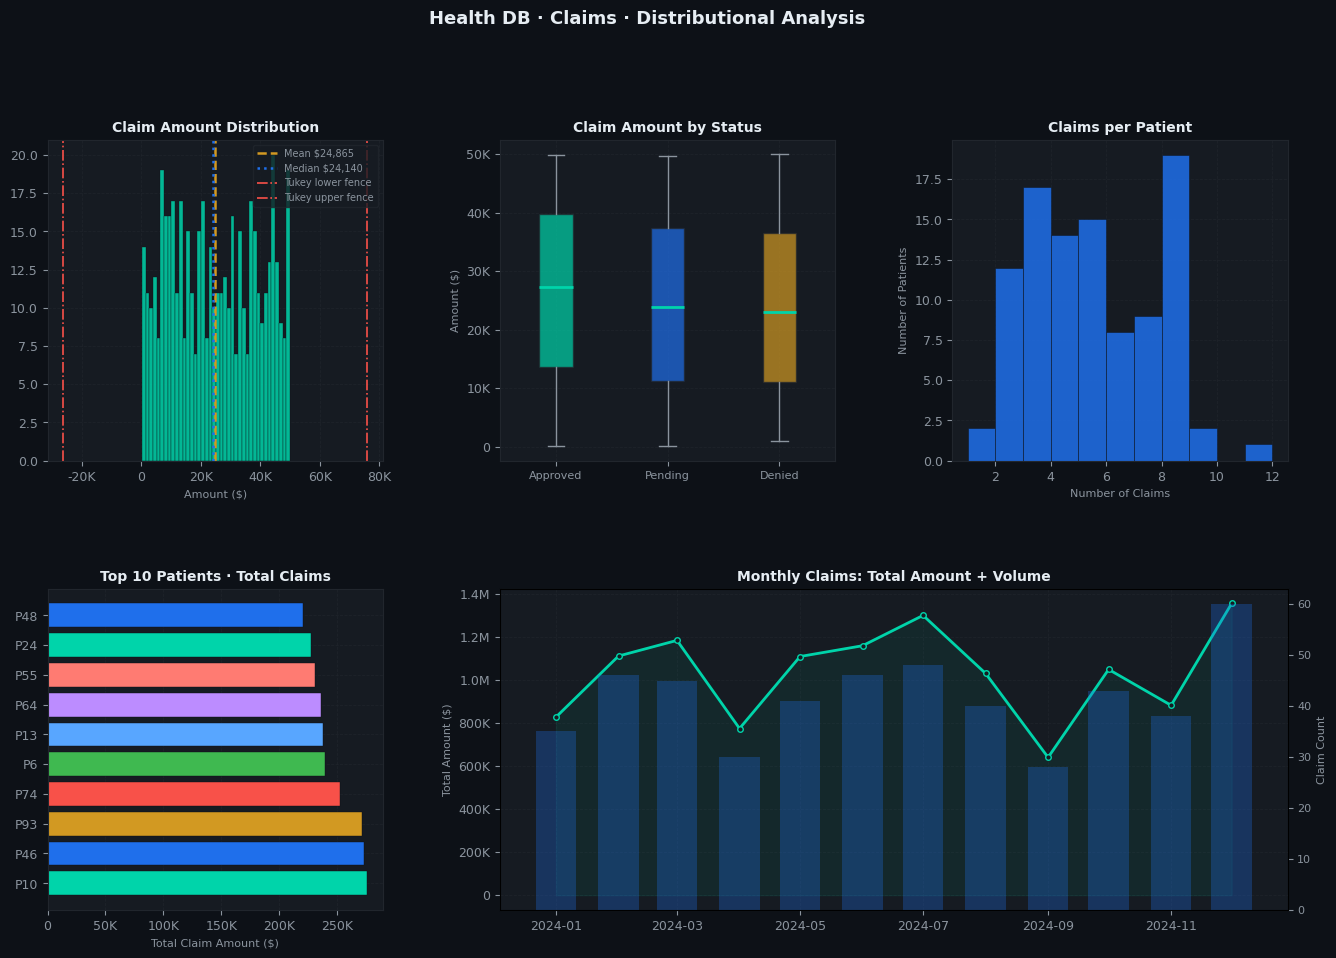

In [6]:
# Four-panel distributional deep-dive 
fig = plt.figure(figsize = (16, 10), 
                 dpi     = 100,
                )

fig.patch.set_facecolor(PALETTE['bg_figure'])

gs  = gridspec.GridSpec(2, 3, figure = fig, hspace = 0.4, wspace = 0.35)

# Histogram of claim_amount
ax1 = fig.add_subplot(gs[0, 0])

apply_bi_theme(fig, ax1)

ax1.hist(df_claims['claim_amount'],
         bins      = 40, 
         color     = PALETTE['accent'],
         edgecolor = PALETTE['bg_figure'], 
         linewidth = 0.3, 
         alpha     = 0.85,
        )

ax1.axvline(ca['mean'],   
            color = PALETTE['accent_3'], 
            lw    = 1.8, 
            ls    = '--', 
            label = f"Mean ${ca['mean']:,.0f}",
           )

ax1.axvline(ca['median'], 
            color = PALETTE['accent_2'], 
            lw    = 1.8, 
            ls    = ':',  
            label = f"Median ${ca['median']:,.0f}",
           )

ax1.axvline(ca['q1'] - 1.5*ca['iqr'], 
            color = PALETTE['series'][3], 
            lw    = 1.2, 
            ls    = '-.', 
            label = 'Tukey lower fence',
           )

ax1.axvline(ca['q3'] + 1.5*ca['iqr'], 
            color = PALETTE['series'][3], 
            lw    = 1.2, 
            ls    = '-.', 
            label = 'Tukey upper fence',
           )

ax1.legend(fontsize   = 7, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax1.set_title('Claim Amount Distribution',  
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax1.set_xlabel('Amount ($)', fontsize = 8)

ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Box plot by status
ax2            = fig.add_subplot(gs[0, 1])
apply_bi_theme(fig, ax2)

statuses       = ['Approved', 'Pending', 'Denied']
data_by_status = [df_claims.loc[df_claims['status']==s, 'claim_amount'].values for s in statuses]

bp             = ax2.boxplot(data_by_status,
                             patch_artist = True, 
                             notch        = False,
                             medianprops  = dict(color     = PALETTE['accent'], 
                                                 linewidth = 2,
                                                ),
                             whiskerprops = dict(color = PALETTE['text_muted']),
                             capprops     = dict(color = PALETTE['text_muted']),
                             flierprops   = dict(marker     = 'o',
                                                 color      = PALETTE['series'][3], 
                                                 markersize = 3, 
                                                 alpha      = 0.5,
                                                )
                            )

for patch, color in zip(bp['boxes'], PALETTE['series'][:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor(PALETTE['grid'])

ax2.set_xticks([1,2,3])
ax2.set_xticklabels(statuses, 
                    fontsize = 8, 
                    color    = PALETTE['text_muted'],
                   )

ax2.set_title('Claim Amount by Status', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax2.set_ylabel('Amount ($)', fontsize = 8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Claims per patient distribution
ax3                = fig.add_subplot(gs[0, 2])

apply_bi_theme(fig, ax3)

claims_per_patient = df_claims.groupby('patient_id').size()

ax3.hist(claims_per_patient,
         bins      = range(1, claims_per_patient.max()+2),
         color     = PALETTE['accent_2'], 
         edgecolor = PALETTE['bg_figure'], 
         linewidth = 0.4, 
         alpha     = 0.85,
        )

ax3.set_title('Claims per Patient', 
              fontsize   = 10, 
              fontweight = 'semibold',
              color      = PALETTE['text_main'],
             )

ax3.set_xlabel('Number of Claims', fontsize = 8)
ax3.set_ylabel('Number of Patients', fontsize = 8)

# Top 10 patients by total claim amount
ax4          = fig.add_subplot(gs[1, 0])

apply_bi_theme(fig, ax4)

top_patients = df_claims.groupby('patient_id')['claim_amount'].sum().nlargest(10)
bars         = ax4.barh([f'P{i}' for i in top_patients.index], 
                        top_patients.values,
                        color     = PALETTE['series'][:10], 
                        edgecolor = PALETTE['bg_figure'], 
                        linewidth = 0.3,
                       )

ax4.set_title('Top 10 Patients · Total Claims', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax4.set_xlabel('Total Claim Amount ($)', fontsize = 8)

ax4.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Claim amount over time (monthly aggregation)
ax5                = fig.add_subplot(gs[1, 1:])

apply_bi_theme(fig, ax5)

df_claims['month'] = df_claims['claim_date'].dt.to_period('M').dt.to_timestamp()

monthly_claims     = df_claims.groupby('month').agg(total_amount = ('claim_amount','sum'),
                                                    count        = ('claim_id','count')
                                                   ).reset_index()

ax5.plot(monthly_claims['month'], 
         monthly_claims['total_amount'],
         color           = PALETTE['accent'], 
         lw              = 2, 
         marker          = 'o', 
         markersize      = 4,
         markerfacecolor = PALETTE['bg_axes'], 
         markeredgecolor = PALETTE['accent'],
        )

ax5.fill_between(monthly_claims['month'], 
                 monthly_claims['total_amount'], 
                 alpha = 0.07, 
                 color = PALETTE['accent'],
                )

ax5b = ax5.twinx()

ax5b.bar(monthly_claims['month'], 
         monthly_claims['count'],
         color  = PALETTE['accent_2'], 
         alpha  = 0.3, 
         width  = 20, 
         label  = 'Claim count',
        )

ax5b.set_ylabel('Claim Count', 
                fontsize = 8, 
                color    = PALETTE['text_muted'],
               )

ax5b.tick_params(colors    = PALETTE['text_muted'], 
                 labelsize = 8,
                )

ax5.set_title('Monthly Claims: Total Amount + Volume', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax5.set_ylabel('Total Amount ($)', fontsize = 8)

ax5.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.xticks(rotation = 35, 
           ha       = 'right', 
           fontsize = 7,
          )

plt.suptitle('Health DB · Claims · Distributional Analysis', 
             fontsize   = 13,
             fontweight = 'bold',
             color      = PALETTE['text_main'], 
             y          = 1.01,
            )

plt.tight_layout()
plt.show()


**Observations:**

- `claim_amount` is approximately **uniform** between \$100 and \$50,000 — mean and median are very close (ratio ≈ 1.0). This differs from real-world medical cost data, which is typically right-skewed log-normal, but is correct for this demo dataset.
- The Tukey fence does **not** flag many outliers in a uniform distribution — because Tukey's fence assumes an approximately bell-shaped bulk distribution. The fences are wide when IQR spans the full range. This is a known limitation of IQR-based outlier detection on uniform data.
- The **box plot by status** shows roughly equal claim amount distributions across Approved, Pending, and Denied — expected, since status is randomly assigned in the demo script with no correlation to amount.
- The **monthly time series** shows no trend — uniform random dates produce flat month-over-month aggregates.


### 3.2 · Patient risk score analysis and chronic condition breakdown

`risk_score` is `uniform(1.0, 9.9)` per patient. We examine whether chronic condition affects risk score — a domain-relevant question even in demo data.


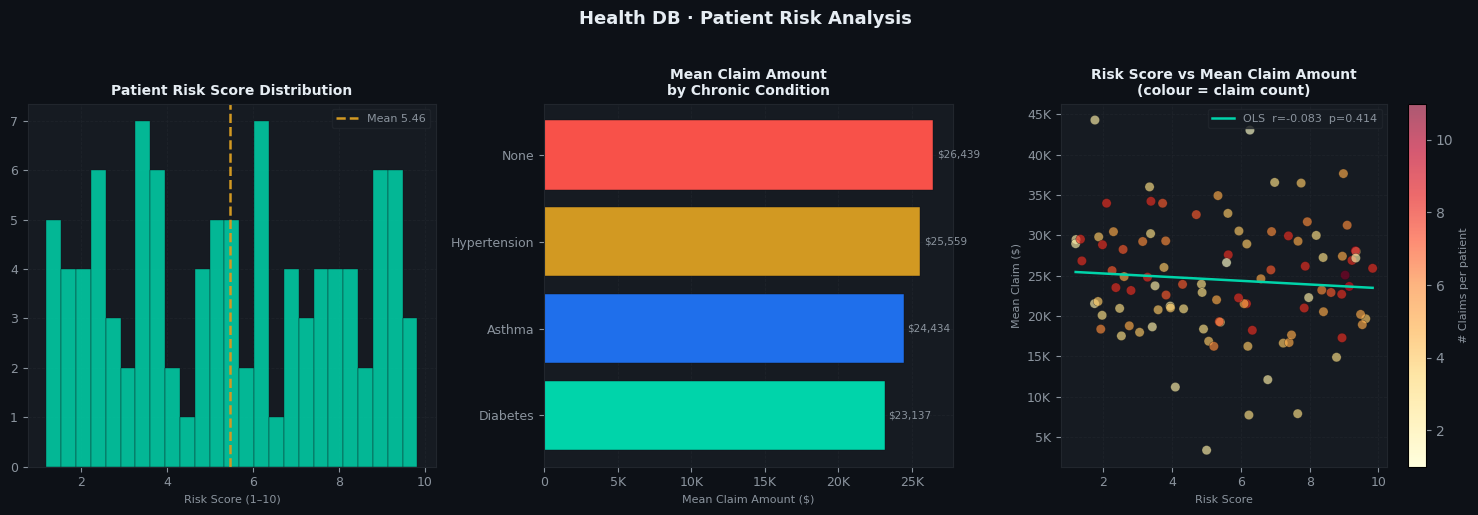

One-way ANOVA — claim_amount across chronic conditions:
  F = 1.2328,  p = 0.2971
  No significant difference at α=0.05
  Expected: not significant — condition is randomly assigned in demo data.


In [7]:
# Merge patients with their claims for patient-level analysis
df_patient_claims = df_claims.merge(df_patients, on = 'patient_id', how = 'left')

# Risk score by chronic condition
fig, axes         = plt.subplots(nrows   = 1, 
                                 ncols   = 3, 
                                 figsize = (15, 5), 
                                 dpi     = 100,
                                )
for ax in axes:
    apply_bi_theme(fig, ax)

# Risk score distribution
ax = axes[0]
ax.hist(df_patients['risk_score'], 
        bins      = 25, 
        color     = PALETTE['accent'],
        edgecolor = PALETTE['bg_figure'], 
        lw        = 0.3, 
        alpha     = 0.85,
       )

ax.axvline(df_patients['risk_score'].mean(), 
           color = PALETTE['accent_3'], 
           lw    = 1.8, 
           ls    = '--',
           label = f"Mean {df_patients['risk_score'].mean():.2f}",
          )

ax.legend(fontsize   = 8, 
          facecolor  = PALETTE['bg_axes'], 
          edgecolor  = PALETTE['grid'], 
          labelcolor = PALETTE['text_muted'],
         )

ax.set_title('Patient Risk Score Distribution', 
             fontsize   = 10, 
             fontweight = 'semibold', 
             color      = PALETTE['text_main'],
            )

ax.set_xlabel('Risk Score (1–10)', fontsize = 8)

# Mean claim amount by chronic condition
ax          = axes[1]
cond_claims = df_patient_claims.groupby('chronic_condition')['claim_amount'].mean().sort_values(ascending = True)
colors      = [PALETTE['series'][i] for i in range(len(cond_claims))]

ax.barh(cond_claims.index, 
        cond_claims.values, 
        color     = colors, 
        edgecolor = PALETTE['bg_figure'], 
        lw        = 0.3,
       )

ax.set_title('Mean Claim Amount\nby Chronic Condition', 
             fontsize   = 10, 
             fontweight = 'semibold', 
             color      = PALETTE['text_main'],
            )

ax.set_xlabel('Mean Claim Amount ($)', fontsize = 8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

for i, (v, label) in enumerate(zip(cond_claims.values, cond_claims.index)):
    ax.text(v * 1.01, i, f'${v:,.0f}', va = 'center', fontsize = 7.5, color = PALETTE['text_muted'])

# Risk score vs mean claim amount per patient (scatter)
ax              = axes[2]
patient_summary = df_patient_claims.groupby('patient_id').agg(mean_claim  = ('claim_amount','mean'),
                                                              num_claims  = ('claim_id','count'),
                                                              risk_score  = ('risk_score','first'),
                                                             ).reset_index()

sc              = ax.scatter(patient_summary['risk_score'], 
                             patient_summary['mean_claim'],
                             c          = patient_summary['num_claims'], 
                             cmap       = 'YlOrRd',
                             s          = 45, 
                             alpha      = 0.65, 
                             edgecolors = PALETTE['bg_figure'], 
                             linewidths = 0.3,
                            )

m, b, r, p, _   = stats.linregress(patient_summary['risk_score'], patient_summary['mean_claim'])
x_line          = np.linspace(patient_summary['risk_score'].min(), patient_summary['risk_score'].max(), 100)

ax.plot(x_line, 
        m*x_line + b, 
        color = PALETTE['accent'], 
        lw    = 1.8,
        label = f'OLS  r={r:.3f}  p={p:.3f}',
       )

cbar = plt.colorbar(sc, ax = ax)
cbar.set_label('# Claims per patient', color = PALETTE['text_muted'], fontsize = 8)

cbar.ax.yaxis.set_tick_params(color = PALETTE['text_muted'])
plt.setp(cbar.ax.yaxis.get_ticklabels(), color = PALETTE['text_muted'])

ax.legend(fontsize   = 8, 
          facecolor  = PALETTE['bg_axes'], 
          edgecolor  = PALETTE['grid'], 
          labelcolor = PALETTE['text_muted'],
         )

ax.set_title('Risk Score vs Mean Claim Amount\n(colour = claim count)', 
             fontsize   = 10, 
             fontweight = 'semibold', 
             color      = PALETTE['text_main'],
            )

ax.set_xlabel('Risk Score', fontsize = 8)
ax.set_ylabel('Mean Claim ($)', fontsize = 8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.suptitle('Health DB · Patient Risk Analysis', 
             fontsize   = 13, 
             fontweight = 'bold',
             color      = PALETTE['text_main'], 
             y          = 1.02,
            )

plt.tight_layout()
plt.show()

# One-way ANOVA: is there a significant difference in claim amounts across chronic conditions?
groups        = [df_patient_claims.loc[df_patient_claims['chronic_condition']==c, 'claim_amount'].values for c in ['Diabetes','Hypertension','Asthma','None']]
f_stat, p_val = stats.f_oneway(*groups)

print(f'One-way ANOVA — claim_amount across chronic conditions:')
print(f'  F = {f_stat:.4f},  p = {p_val:.4f}')
print(f'  {"No significant difference" if p_val > 0.05 else "Significant difference"} at α=0.05')
print('  Expected: not significant — condition is randomly assigned in demo data.')


**Statistical note — One-way ANOVA:**  
The F-test asks: do the group means differ more than we would expect by chance?  
With random assignment of chronic conditions in the demo script, we expect p > 0.05 (no significant difference). This is a built-in sanity check — if the ANOVA were significant here, it would indicate a data generation bug, not a real clinical finding.

In a real health BI scenario with actual PHI, this ANOVA would be a starting point for understanding cost drivers by diagnostic category.


## 4 · Outlier detection — `detect_outliers()`

### IQR (Tukey fence) vs Z-score (3σ): when each method is appropriate

The choice of outlier detection method depends on the distributional shape of the variable.

| Method | Assumption | Formula | Appropriate for |
|---|---|---|---|
| **Tukey IQR fence** | Non-parametric | `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` | Skewed, heavy-tailed, or unknown distributions |
| **Z-score (3σ)** | Gaussian (normal) | `[μ − 3σ, μ + 3σ]` | Symmetric, approximately normal columns |

We demonstrate this on three columns with genuinely different distributions:
- `df_transactions['amount']` — uniform(10, 5000): the IQR and Z-score fences behave differently
- `df_daily_steps['step_count']` — uniform(2000, 15000): wide uniform, very few outliers expected
- `df_subscriptions['monthly_fee']` — uniform(9.99, 299.99): narrow uniform


In [8]:
# Apply both methods to three columns, compare results
test_cases    = [(df_transactions, 'amount', 'Finance: transaction amount'),
                 (df_daily_steps, 'step_count', 'IoT: daily step count'),
                 (df_subscriptions, 'monthly_fee', 'Finance: subscription monthly fee'),
                 (df_procedures, 'cost', 'Health: procedure cost'),
                 (df_opportunities, 'opportunity_value', 'Sales: opportunity value'),
                ]

results_table = list()

for df_, col, label in test_cases:
    iqr_r = da.detect_outliers(df_, col, 'iqr')
    z_r   = da.detect_outliers(df_, col, 'zscore')
    results_table.append({'Dataset'         : label,
                          'Column'          : col,
                          'N'               : len(df_[col].dropna()),
                          'IQR outliers'    : iqr_r['total_outliers'],
                          'IQR %'           : iqr_r['outlier_percentage'],
                          'IQR upper fence' : round(iqr_r['bounds']['upper'], 2),
                          'Z outliers'      : z_r['total_outliers'],
                          'Z %'             : z_r['outlier_percentage'],
                          'Z upper fence'   : round(z_r['bounds']['upper'], 2),
                        })

df_results = pd.DataFrame(results_table)

print(df_results.to_string(index = False))


                          Dataset            Column     N  IQR outliers  IQR %  IQR upper fence  Z outliers  Z %  Z upper fence
      Finance: transaction amount            amount  1000             0    0.0          7246.46           0  0.0        6632.17
            IoT: daily step count        step_count 18250             0    0.0         21583.50           0  0.0       19816.49
Finance: subscription monthly fee       monthly_fee   200             0    0.0           382.97           0  0.0         392.59
           Health: procedure cost              cost   505             0    0.0         11912.14           0  0.0       10790.45
         Sales: opportunity value opportunity_value   150             0    0.0        167369.71           0  0.0      143223.15


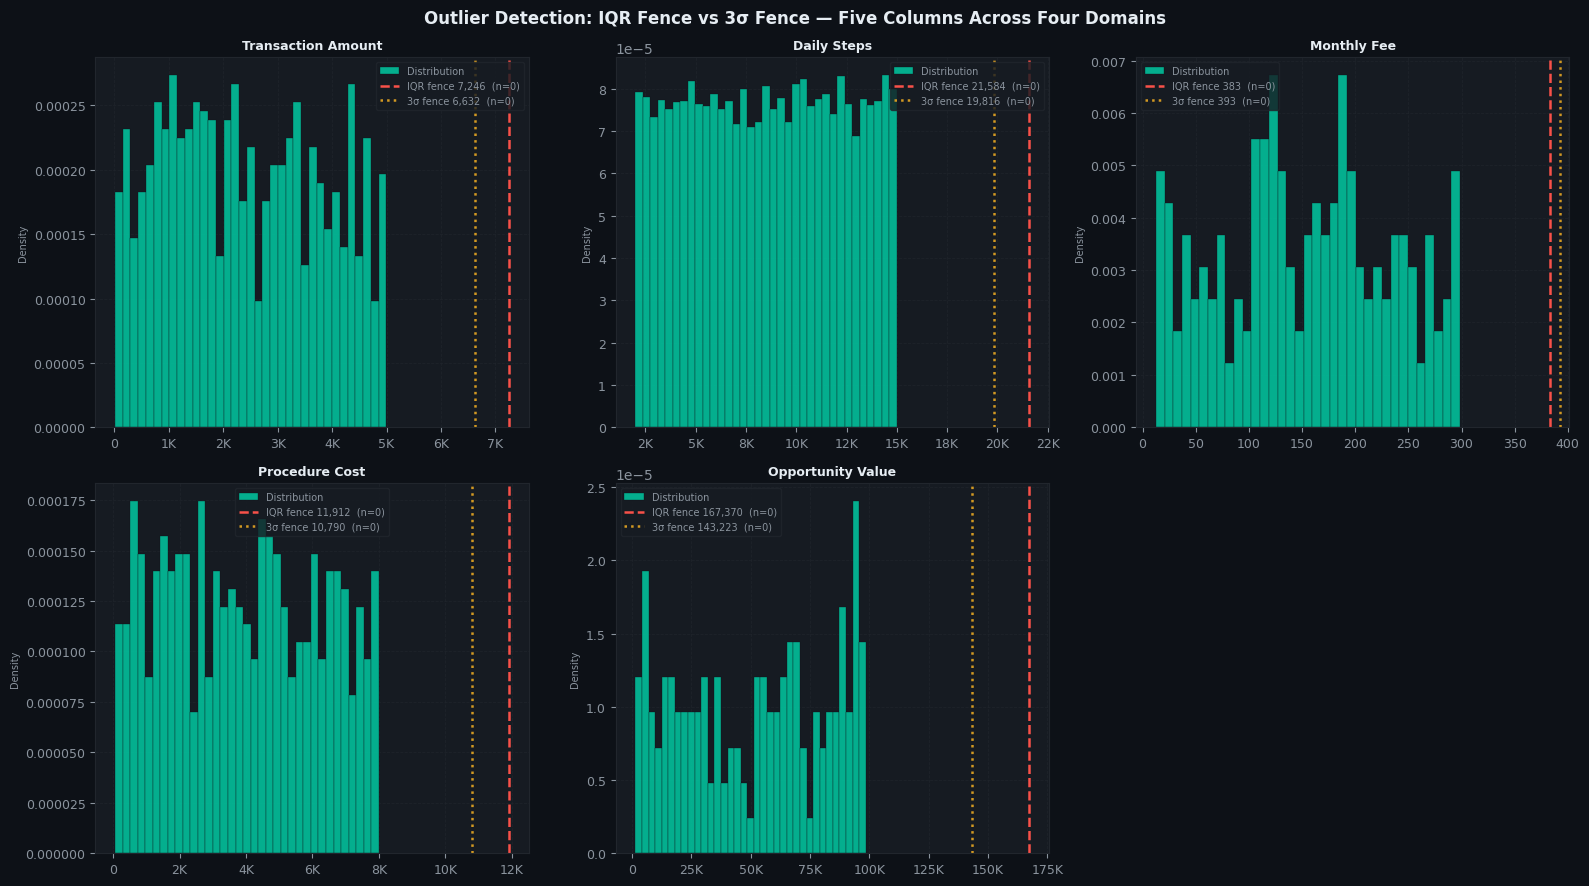

In [9]:
# Visual comparison: IQR vs Z-score on transaction amount
fig, axes      = plt.subplots(nrows   = 2, 
                              ncols   = 3, 
                              figsize = (16, 9), 
                              dpi     = 100,
                             )

fig.patch.set_facecolor(PALETTE['bg_figure'])

test_cases_vis = [(df_transactions, 'amount', 'Transaction Amount'),
                  (df_daily_steps, 'step_count', 'Daily Steps'),
                  (df_subscriptions, 'monthly_fee', 'Monthly Fee'),
                  (df_procedures, 'cost', 'Procedure Cost'),
                  (df_opportunities, 'opportunity_value','Opportunity Value'),
                 ]

for idx, (df_, col, label) in enumerate(test_cases_vis):
    ax     = axes[idx // 3][idx % 3]

    apply_bi_theme(fig, ax)

    iqr_r  = da.detect_outliers(df_, col, 'iqr')
    z_r    = da.detect_outliers(df_, col, 'zscore')
    series = df_[col].dropna()

    ax.hist(series, 
            bins      = 35, 
            color     = PALETTE['accent'], 
            edgecolor = PALETTE['bg_figure'],
            lw        = 0.3, 
            alpha     = 0.8,
            density   = True, 
            label     = 'Distribution',
           )

    ax.axvline(iqr_r['bounds']['upper'], 
               color = PALETTE['series'][3],   
               lw    = 1.8, 
               ls    = '--',
               label = f"IQR fence {iqr_r['bounds']['upper']:,.0f}  (n={iqr_r['total_outliers']})",
              )

    ax.axvline(z_r['bounds']['upper'],   
               color = PALETTE['accent_3'], 
               lw    = 1.8, 
               ls    = ':',
               label = f"3σ fence {z_r['bounds']['upper']:,.0f}  (n={z_r['total_outliers']})",
              )

    ax.legend(fontsize   = 7, 
              facecolor  = PALETTE['bg_axes'], 
              edgecolor  = PALETTE['grid'],
              labelcolor = PALETTE['text_muted'],
             )

    ax.set_title(label, 
                 fontsize   = 9, 
                 fontweight = 'semibold', 
                 color      = PALETTE['text_main'],
                )

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

    ax.set_ylabel('Density', fontsize = 7)

# Hide unused 6th panel
axes[1][2].set_visible(False)

plt.suptitle('Outlier Detection: IQR Fence vs 3σ Fence — Five Columns Across Four Domains',
             fontsize   = 12, 
             fontweight = 'bold', 
             color      = PALETTE['text_main'],
            )

plt.tight_layout()
plt.show()


**Key observations:**

- For **uniform distributions** (step_count, monthly_fee, amount), both methods detect very few outliers — because uniform distributions have no heavy tails. The bulk of the data fills the entire range, so no single point is far from the others relative to spread. This is correct behaviour for Tukey's fence on uniform data.
- **IQR upper fence** is typically lower than the **3σ upper fence** for uniform distributions. The IQR of a Uniform(a,b) is `(b-a)/2`, giving a Tukey upper fence at `b + (b-a)/4`. The 3σ fence is at `μ + 3σ = (a+b)/2 + 3(b-a)/(2√3) ≈ (a+b)/2 + 0.866(b-a)`. For wide uniforms, 3σ is more permissive.
- **Practical implication for production:** The default method in `settings.py` is `iqr`. For a column you know to be normally distributed (e.g., a standardised score), switch to `zscore` via the configuration.


## 5 · Finance DB analysis

### 5.1 · Transaction analysis and payment method breakdown

The finance domain has three tables with an important structural relationship:  
`payment_failures` only exists for transactions where `status = 'Failed'`.  
This is an **edge case by design** — the demo script explicitly filters `[t for t in transactions if t[3] == 'Failed']`.  
A naive query joining all three tables without understanding this will produce incorrect failure rates.


In [10]:
# Summary stats on transactions
txn_stats = da.generate_summary_statistics(df_transactions)

print('Transaction amounts:')
ts_amt    = txn_stats['numerical_summary']['amount']

for k, v in ts_amt.items():
    print(f'  {k:8}: ${v:>12,.2f}' if v else f'  {k:8}: None')

print()

# Status breakdown
print('Status distribution:')
for status, cnt in txn_stats['categorical_summary']['status']['most_common'].items():
    pct = cnt / len(df_transactions) * 100
    print(f'  {status:12}: {cnt:>4}  ({pct:.1f}%)')

print()

print(f'payment_failures table: {len(df_failures)} rows  '
      f'(should match Failed count above)')
      
print(f'Verify: Failed txns = '
      f'{(df_transactions.status == "Failed").sum()}, failures = {len(df_failures)}')

Transaction amounts:
  mean    : $    2,401.22
  median  : $    2,270.06
  std     : $    1,410.32
  min     : $       11.57
  max     : $    4,998.58
  q1      : $    1,190.63
  q3      : $    3,612.96
  iqr     : $    2,422.33

Status distribution:
  Completed   :  558  (55.8%)
  Failed      :  325  (32.5%)
  Pending     :  117  (11.7%)

payment_failures table: 325 rows  (should match Failed count above)
Verify: Failed txns = 325, failures = 325


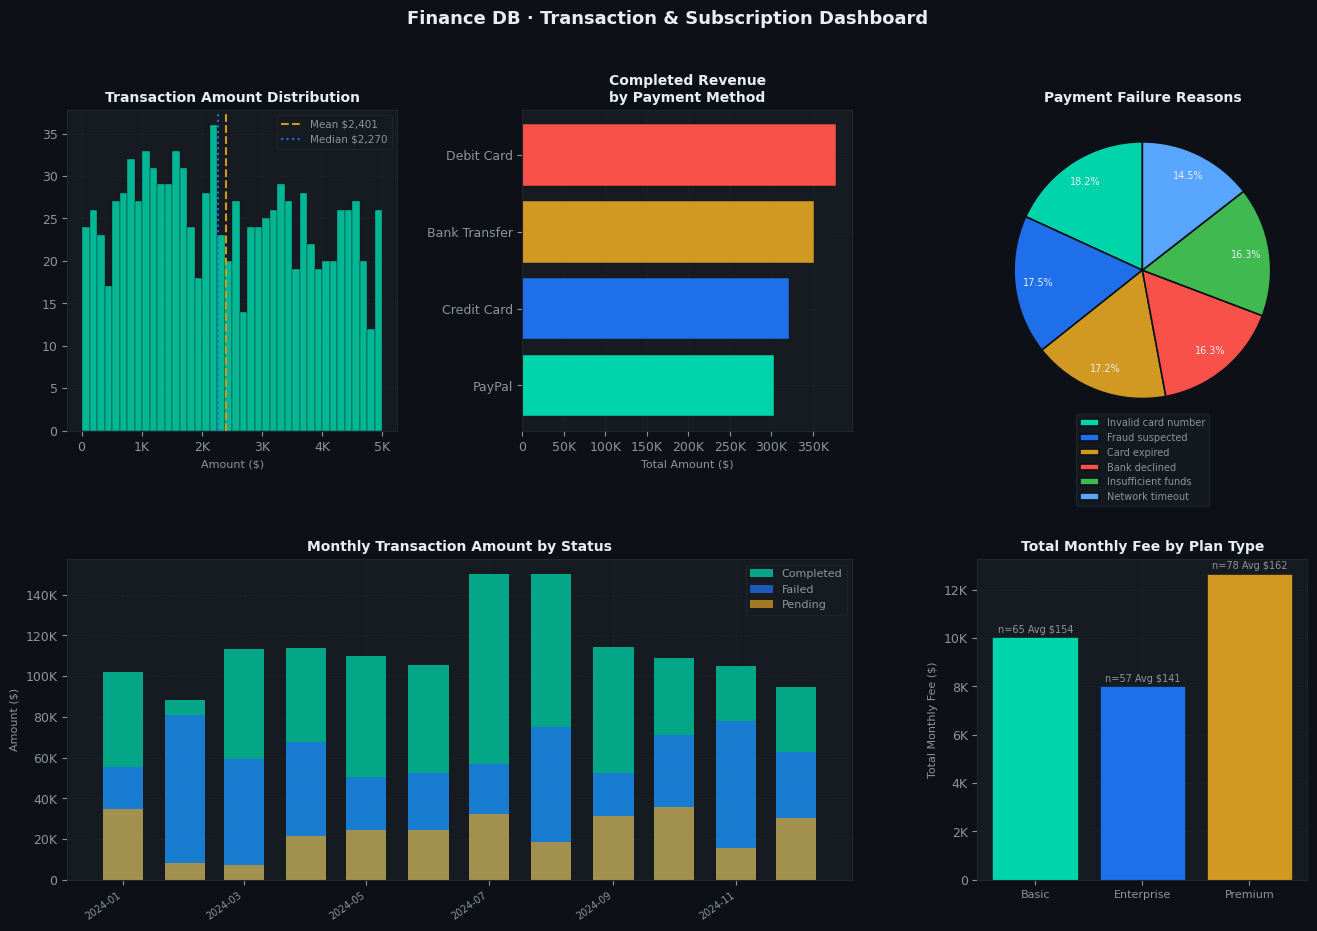

In [12]:
# Finance visualisation: 4-panel dashboard 
fig = plt.figure(figsize = (16, 10), dpi = 100)

fig.patch.set_facecolor(PALETTE['bg_figure'])

gs  = gridspec.GridSpec(nrows  = 2,
                        ncols  = 3, 
                        figure = fig, 
                        hspace = 0.4,
                        wspace = 0.38,
                       )


# Transaction amount histogram
ax1 = fig.add_subplot(gs[0, 0])
apply_bi_theme(fig, ax1)

ax1.hist(df_transactions['amount'], 
         bins      = 40, 
         color     = PALETTE['accent'],
         edgecolor = PALETTE['bg_figure'], 
         lw        = 0.3, 
         alpha     = 0.85,
        )

ax1.axvline(ts_amt['mean'],   
            color = PALETTE['accent_3'], 
            lw    = 1.5, 
            ls    = '--', 
            label = f"Mean ${ts_amt['mean']:,.0f}",
           )

ax1.axvline(ts_amt['median'], 
            color = PALETTE['accent_2'], 
            lw    = 1.5, 
            ls    = ':',  
            label = f"Median ${ts_amt['median']:,.0f}",
           )

ax1.legend(fontsize   = 7.5, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax1.set_title('Transaction Amount Distribution', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax1.set_xlabel('Amount ($)', fontsize = 8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Revenue by payment method
ax2        = fig.add_subplot(gs[0, 1])

apply_bi_theme(fig, ax2)

pm_revenue = df_transactions[df_transactions['status']=='Completed'].groupby('payment_method')['amount'].sum().sort_values()
bars       = ax2.barh(pm_revenue.index, 
                      pm_revenue.values,
                      color     = PALETTE['series'][:4], 
                      edgecolor = PALETTE['bg_figure'], 
                      lw        = 0.3,
                     )

ax2.set_title('Completed Revenue\nby Payment Method', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax2.set_xlabel('Total Amount ($)', fontsize = 8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Failure reason breakdown
ax3                      = fig.add_subplot(gs[0, 2])

apply_bi_theme(fig, ax3)

reason_counts            = df_failures['failure_reason'].value_counts()
wedges, texts, autotexts = ax3.pie(reason_counts.values,
                                   labels      = None,
                                   colors      = PALETTE['series'][:len(reason_counts)],
                                   autopct     = '%1.1f%%', 
                                   startangle  = 90,
                                   pctdistance = 0.82,
                                   wedgeprops  = dict(edgecolor = PALETTE['bg_figure'], 
                                                      linewidth = 1.2,
                                                     ),
                                  )
for t in autotexts:
    t.set_color(PALETTE['text_main'])
    t.set_fontsize(7)

ax3.legend(reason_counts.index, 
           fontsize       = 7, 
           loc            = 'lower center',
           facecolor      = PALETTE['bg_axes'], 
           edgecolor      = PALETTE['grid'], 
           labelcolor     = PALETTE['text_muted'],
           bbox_to_anchor = (0.5, -0.25),
          )

ax3.set_title('Payment Failure Reasons', 
              fontsize   = 10, 
              fontweight = 'semibold',
              color      = PALETTE['text_main'],
             )

ax3.set_facecolor(PALETTE['bg_figure'])

# Monthly transaction volume + amount
ax4                      = fig.add_subplot(gs[1, :2])

apply_bi_theme(fig, ax4)

df_transactions['month'] = df_transactions['transaction_date'].dt.to_period('M').dt.to_timestamp()

monthly_txn              = df_transactions.groupby(['month','status'])['amount'].sum().unstack(fill_value = 0)

for status, color in zip(monthly_txn.columns, PALETTE['series']):
    ax4.bar(monthly_txn.index, 
            monthly_txn[status], 
            label = status,
            color = color, 
            alpha = 0.75,
            width = 20,
           )

ax4.set_title('Monthly Transaction Amount by Status', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax4.set_ylabel('Amount ($)', fontsize = 8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

ax4.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

plt.setp(ax4.get_xticklabels(), rotation = 35, ha = 'right', fontsize = 7)

# Subscription plan distribution
ax5      = fig.add_subplot(gs[1, 2])

apply_bi_theme(fig, ax5)

plan_rev = df_subscriptions.groupby('plan_type')['monthly_fee'].agg(['sum','count','mean'])
x        = np.arange(len(plan_rev))
bars     = ax5.bar(x, 
                   plan_rev['sum'], 
                   color     = PALETTE['series'][:3],
                   edgecolor = PALETTE['bg_figure'], 
                   lw        = 0.4,
                  )

ax5.set_xticks(x)

ax5.set_xticklabels(plan_rev.index, 
                    fontsize = 8, 
                    color    = PALETTE['text_muted'],
                   )

ax5.set_title('Total Monthly Fee by Plan Type', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax5.set_ylabel('Total Monthly Fee ($)', fontsize = 8)

ax5.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

for bar, (plan, row) in zip(bars, plan_rev.iterrows()):
    ax5.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height()*1.01,
             f"n={int(row['count'])} Avg ${row['mean']:,.0f}",
             ha       = 'center', 
             va       = 'bottom', 
             fontsize = 7, 
             color    = PALETTE['text_muted'],
            )

plt.suptitle('Finance DB · Transaction & Subscription Dashboard', 
             fontsize   = 13,
             fontweight = 'bold', 
             color      = PALETTE['text_main'],
            )

plt.tight_layout()
plt.show()


### 5.2 · Subscription renewal edge case

All subscriptions have `renewal_date = start_date + 30 days` by construction in the demo script.  
This means every subscription expires within the data window — a realistic churn scenario.  
The analysis below quantifies how many have lapsed by the end of the data period.


In [13]:
# Subscription lapse analysis
end_date                        = pd.Timestamp('2024-12-31')
df_subscriptions['is_lapsed']   = df_subscriptions['renewal_date'] < end_date

lapse_by_plan                   = df_subscriptions.groupby('plan_type').agg(total      = ('subscription_id','count'),
                                                                            lapsed     = ('is_lapsed','sum'),
                                                                            active_now = ('status', lambda x: (x=='Active').sum()),
                                                                            avg_fee    = ('monthly_fee','mean'),
                                                                           ).reset_index()

lapse_by_plan['lapse_rate_pct'] = (lapse_by_plan['lapsed'] / lapse_by_plan['total'] * 100).round(1)

print('Subscription lapse analysis (renewal_date < 2024-12-31):')
print(lapse_by_plan[['plan_type','total','lapsed','lapse_rate_pct','active_now','avg_fee']].to_string(index = False))

print()

print('Note: ALL subscriptions show 100% lapse rate because renewal_date = start_date + 30 days.')
print('This is an intentional edge case in the demo data that a real BI query must handle:')
print('  → Do NOT use renewal_date < today() as a churn indicator without domain context.')


Subscription lapse analysis (renewal_date < 2024-12-31):
 plan_type  total  lapsed  lapse_rate_pct  active_now    avg_fee
     Basic     65      65           100.0          17 154.454154
Enterprise     57      57           100.0          13 140.914035
   Premium     78      78           100.0          26 162.035769

Note: ALL subscriptions show 100% lapse rate because renewal_date = start_date + 30 days.
This is an intentional edge case in the demo data that a real BI query must handle:
  → Do NOT use renewal_date < today() as a churn indicator without domain context.


## 6 · Sales DB analysis

### 6.1 · Correlation analysis — `generate_correlation_analysis()`

The sales domain has the richest set of numeric columns suitable for correlation analysis:  
`total_sales`, `quota`, `performance_score`, `quota_attainment`, `opportunity_value`, `probability`.

**Pearson r is appropriate here** because all columns are continuous and numeric (no bounded integers, no categorical encodings).  
Spearman ρ would be more appropriate for `performance_score` if it were an ordinal rank, but as a continuous `uniform(60, 100)` it is suitable for Pearson.


In [14]:
# Correlation analysis on sales rep performance
corr_result = da.generate_correlation_analysis(df_sales_reps)

print('Top correlations (ranked by |r|):')
for item in corr_result['top_correlations']:
    bar = '█' * int(abs(item['correlation']) * 20)
    print(f"  {item['column1']:20} × {item['column2']:20}  r={item['correlation']:+.4f}  {bar}")

print()

if corr_result['strong_positive']:
    print('Strong positive (r > 0.70):')
    for item in corr_result['strong_positive']:
        print(f"  {item['column1']} × {item['column2']}  r={item['correlation']:+.4f}")
        
else:
    print('No strong correlations (|r| > 0.70)')
    print('Expected: quota and total_sales are independently uniform — no structural correlation.')
    print('Quota attainment should correlate strongly with total_sales (computed column).')

Top correlations (ranked by |r|):
  quota                × quota_attainment      r=-0.6821  █████████████
  total_sales          × quota_attainment      r=+0.6052  ████████████
  performance_score    × quota_attainment      r=-0.2139  ████
  quota                × performance_score     r=+0.0910  █
  total_sales          × quota                 r=-0.0471  
  total_sales          × performance_score     r=-0.0294  

No strong correlations (|r| > 0.70)
Expected: quota and total_sales are independently uniform — no structural correlation.
Quota attainment should correlate strongly with total_sales (computed column).


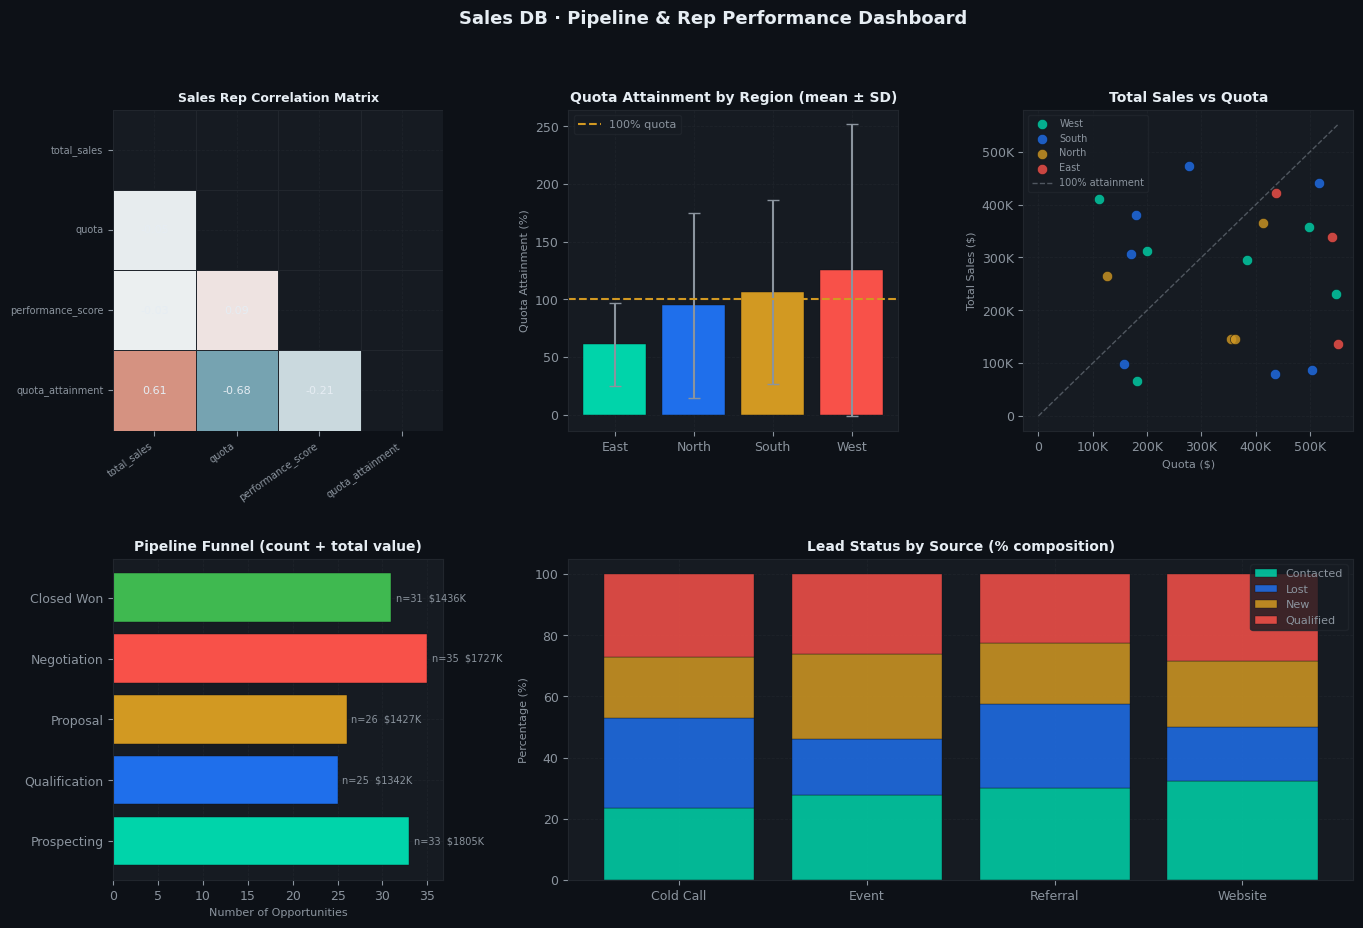

Chi-square test — lead status independence from source:
  χ² = 6.7014,  df = 9,  p = 0.6682
  Independent (no association)
  Expected: independent — status assigned randomly in demo script.


In [15]:
# Sales analysis: 5-panel dashboard
fig = plt.figure(figsize = (16, 10), dpi = 100)

fig.patch.set_facecolor(PALETTE['bg_figure'])

gs  = gridspec.GridSpec(nrows  = 2, 
                        ncols  = 3, 
                        figure = fig, 
                        hspace = 0.4, 
                        wspace = 0.38,
                       )

# Correlation heatmap
ax1            = fig.add_subplot(gs[0, 0])

apply_bi_theme(fig, ax1)

num_cols_sales = [c for c in df_sales_reps.select_dtypes(include='number').columns if not c.lower().endswith('_id') and c != 'rep_id']
cm             = df_sales_reps[num_cols_sales].corr()
mask           = np.triu(np.ones_like(cm, dtype = bool))
cmap           = sns.diverging_palette(220, 20, as_cmap = True)

sns.heatmap(cm, 
            mask       = mask, 
            cmap       = cmap, 
            vmin       = -1,
            vmax       = 1, 
            center     = 0,
            annot      = True, 
            fmt        = '.2f', 
            linewidths = 0.5, 
            linecolor  = PALETTE['grid'],
            ax         = ax1, 
            annot_kws  = {'size'  : 8, 
                          'color' : PALETTE['text_main'],
                         },
            cbar       = False,
           )

ax1.set_title(label      = 'Sales Rep Correlation Matrix', 
              fontsize   = 9, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax1.tick_params(colors = PALETTE['text_muted'], labelsize = 7)
plt.setp(ax1.get_xticklabels(), rotation = 35, ha = 'right')

# Quota attainment by region
ax2           = fig.add_subplot(gs[0, 1])

apply_bi_theme(fig, ax2)

region_attain = df_sales_reps.groupby('region')['quota_attainment'].agg(['mean','std']).reset_index()
bars          = ax2.bar(region_attain['region'], 
                        region_attain['mean'],
                        color     = PALETTE['series'][:4], 
                        edgecolor = PALETTE['bg_figure'], 
                        lw        = 0.3,
                       )

ax2.errorbar(region_attain['region'], 
             region_attain['mean'], 
             yerr    = region_attain['std'],
             fmt     = 'none', 
             color   = PALETTE['text_muted'], 
             capsize = 4, 
             lw      = 1.5,
            )

ax2.axhline(100, color = PALETTE['accent_3'], lw = 1.5, ls = '--', label = '100% quota')
ax2.set_title(label      = 'Quota Attainment by Region (mean ± SD)', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax2.set_ylabel('Quota Attainment (%)', fontsize = 8)

ax2.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

# Total sales vs quota scatter
ax3           = fig.add_subplot(gs[0, 2])

apply_bi_theme(fig, ax3)

regions       = df_sales_reps['region'].unique()
region_colors = {r: PALETTE['series'][i] for i, r in enumerate(regions)}

for region in regions:
    mask_r = df_sales_reps['region'] == region

    ax3.scatter(df_sales_reps.loc[mask_r, 'quota'],
                df_sales_reps.loc[mask_r, 'total_sales'],
                color      = region_colors[region], 
                s          = 55, 
                alpha      = 0.8,
                edgecolors = PALETTE['bg_figure'], 
                lw         = 0.5, 
                label      = region,
               )
# Perfect attainment diagonal
max_val = max(df_sales_reps[['quota','total_sales']].max())

ax3.plot([0, max_val], 
         [0, max_val], 
         color = PALETTE['text_muted'], 
         lw    = 1, 
         ls    = '--', 
         alpha = 0.5, 
         label = '100% attainment',
        )

ax3.legend(fontsize   = 7, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax3.set_title(label      = 'Total Sales vs Quota', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax3.set_xlabel('Quota ($)', fontsize = 8)
ax3.set_ylabel('Total Sales ($)', fontsize = 8)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Pipeline funnel
ax4          = fig.add_subplot(gs[1, 0])

apply_bi_theme(fig, ax4)

stage_order  = ['Prospecting','Qualification','Proposal','Negotiation','Closed Won']
stage_counts = df_opportunities['stage'].value_counts().reindex(stage_order).fillna(0)
stage_values = df_opportunities.groupby('stage')['opportunity_value'].sum().reindex(stage_order).fillna(0)
bars         = ax4.barh(stage_order, 
                        stage_counts.values,
                        color     = PALETTE['series'][:5], 
                        edgecolor = PALETTE['bg_figure'], 
                        lw        = 0.3,
                       )

for i, (cnt, val) in enumerate(zip(stage_counts.values, stage_values.values)):
    ax4.text(x        = cnt + 0.5, 
             y        = i, 
             s        = f'n={int(cnt)}  ${val/1000:.0f}K', 
             va       = 'center', 
             fontsize = 7, 
             color    = PALETTE['text_muted'],
            )

ax4.set_title(label      = 'Pipeline Funnel (count + total value)', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax4.set_xlabel('Number of Opportunities', fontsize = 8)

# Lead source conversion
ax5             = fig.add_subplot(gs[1, 1:])

apply_bi_theme(fig, ax5)

lead_status     = pd.crosstab(df_leads['source'], df_leads['status'])
lead_status_pct = lead_status.div(lead_status.sum(axis=1), axis=0) * 100
bottom          = np.zeros(len(lead_status_pct))

for i, (col, color) in enumerate(zip(lead_status_pct.columns, PALETTE['series'])):
    ax5.bar(lead_status_pct.index, 
            lead_status_pct[col], 
            bottom    = bottom,
            label     = col, 
            color     = color, 
            alpha     = 0.85, 
            edgecolor = PALETTE['bg_figure'], 
            lw        = 0.3,
           )

    bottom += lead_status_pct[col].values

ax5.set_title(label      = 'Lead Status by Source (% composition)', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax5.set_ylabel('Percentage (%)', fontsize = 8)
ax5.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

plt.suptitle(t          = 'Sales DB · Pipeline & Rep Performance Dashboard', 
             fontsize   = 13,
             fontweight = 'bold', 
             color      = PALETTE['text_main'],
            )

plt.tight_layout()
plt.show()

# Chi-square test: is lead status independent of source?
chi2, p, dof, expected = chi2_contingency(lead_status)

print(f'Chi-square test — lead status independence from source:')
print(f'  χ² = {chi2:.4f},  df = {dof},  p = {p:.4f}')
print(f'  {"Independent (no association)" if p > 0.05 else "Significant association detected"}')
print('  Expected: independent — status assigned randomly in demo script.')


## 7 · IoT DB analysis — time series across 50 users × 365 days

The IoT domain is the largest: 50 users × 365 days = 18,250 rows per table.  
Three tables: `daily_steps`, `heart_rate_avg`, `sleep_hours`.

### 7.1 · Time-series analysis — `generate_time_series_analysis()`

For the IoT domain, the time-series method is most natural: `date` is the time axis, and we have three value columns.  
The method computes OLS slope, R², CoV, and period delta.

**CoV (Coefficient of Variation)** = σ/μ × 100 is the right volatility metric here because it is unit-free — it allows comparing step-count volatility (thousands of steps) against sleep volatility (hours) on the same scale.


In [16]:
# IoT time-series: daily averages across all 50 users 
daily_avg_steps         = df_daily_steps.groupby('date')['step_count'].mean().reset_index()
daily_avg_steps.columns = ['date', 'avg_step_count']

daily_avg_hr            = df_heart_rate.groupby('date')['avg_heart_rate'].mean().reset_index()
daily_avg_sleep         = df_sleep.groupby('date')['sleep_duration_hours'].mean().reset_index()

# Run time-series analysis on all three
ts_steps                = da.generate_time_series_analysis(daily_avg_steps, 'date', 'avg_step_count')
ts_hr                   = da.generate_time_series_analysis(daily_avg_hr,    'date', 'avg_heart_rate')
ts_sleep                = da.generate_time_series_analysis(daily_avg_sleep, 'date', 'sleep_duration_hours')

print('IoT Time-Series Analysis (50-user daily averages, 2024)')

print()

for label, result in [('Daily Steps (avg)', ts_steps), ('Heart Rate (avg)', ts_hr), ('Sleep Hours (avg)', ts_sleep)]:
    print(f'  {label}')
    print(f'    Date range  : {result["date_range"]["start"]} → {result["date_range"]["end"]}')
    print(f'    Data points : {result["data_points"]}')
    print(f'    Trend       : {result["overall_trend"].upper()}')
    print(f'    Slope       : {result["trend_slope"]:.6f} / day')
    print(f'    R²          : {result["r_squared"]:.4f}  ({"strong" if result["r_squared"]>0.7 else "weak"} linear fit)')
    cov = result['volatility']['coefficient_of_variation_pct']
    print(f'    CoV         : {cov}%  (day-to-day volatility relative to mean)')
    print(f'    Period Δ    : {result["recent_trend"]["change_pct"]:+.2f}%')
    
    print()


IoT Time-Series Analysis (50-user daily averages, 2024)

  Daily Steps (avg)
    Date range  : 2024-01-01 → 2024-12-30
    Data points : 365
    Trend       : FLAT
    Slope       : -0.157428 / day
    R²          : 0.0009  (weak linear fit)
    CoV         : 6.45%  (day-to-day volatility relative to mean)
    Period Δ    : -0.69%

  Heart Rate (avg)
    Date range  : 2024-01-01 → 2024-12-30
    Data points : 365
    Trend       : FLAT
    Slope       : -0.000312 / day
    R²          : 0.0004  (weak linear fit)
    CoV         : 2.09%  (day-to-day volatility relative to mean)
    Period Δ    : -0.12%

  Sleep Hours (avg)
    Date range  : 2024-01-01 → 2024-12-30
    Data points : 365
    Trend       : FLAT
    Slope       : -0.000051 / day
    R²          : 0.0005  (weak linear fit)
    CoV         : 3.56%  (day-to-day volatility relative to mean)
    Period Δ    : +0.01%



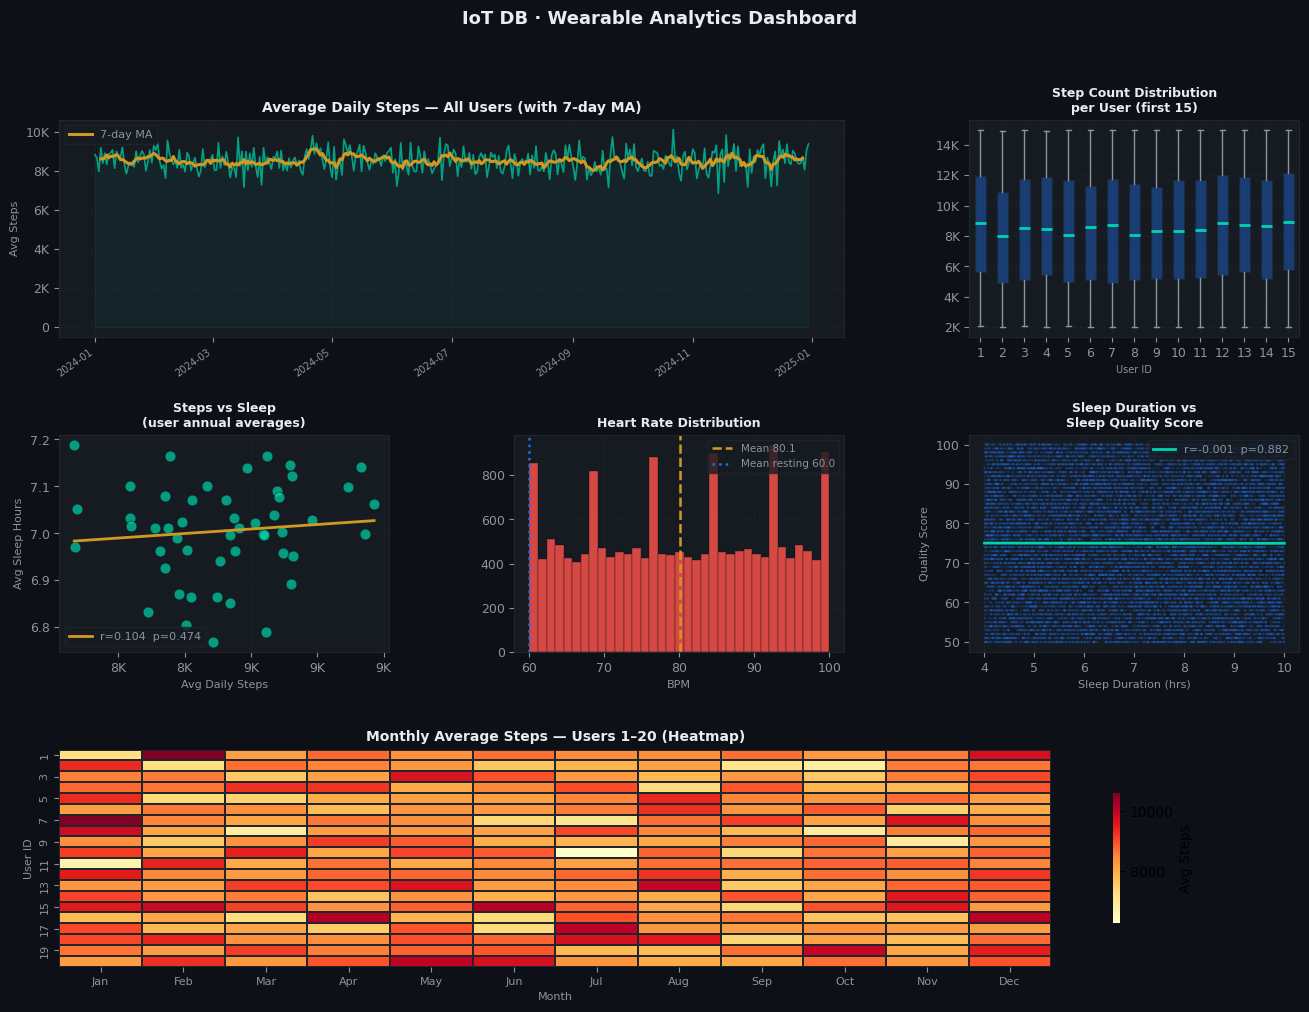

In [18]:
# IoT dashboard: 6-panel
fig = plt.figure(figsize = (16, 11), dpi = 100)

fig.patch.set_facecolor(PALETTE['bg_figure'])

gs  = gridspec.GridSpec(nrows   = 3, 
                        ncols   = 3, 
                        figure  = fig, 
                        hspace  = 0.45, 
                        wspace  = 0.38,
                       )

# Daily avg steps over time
ax1 = fig.add_subplot(gs[0, :2])

apply_bi_theme(fig, ax1)

ax1.plot(daily_avg_steps['date'], 
         daily_avg_steps['avg_step_count'],
         color = PALETTE['accent'], 
         lw    = 1.2, 
         alpha = 0.7,
        )

# 7-day rolling average
rolling = daily_avg_steps['avg_step_count'].rolling(7, center = True).mean()

ax1.plot(daily_avg_steps['date'], 
         rolling, 
         color = PALETTE['accent_3'], 
         lw    = 2.2, 
         label = '7-day MA',
        )

ax1.fill_between(daily_avg_steps['date'], 
                 daily_avg_steps['avg_step_count'], 
                 alpha = 0.05, 
                 color = PALETTE['accent'],
                )

ax1.set_title('Average Daily Steps — All Users (with 7-day MA)', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax1.set_ylabel('Avg Steps', fontsize = 8)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

ax1.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'],
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

plt.setp(ax1.get_xticklabels(), rotation = 35, ha = 'right', fontsize = 7)

# Step count distribution per user (box per user, show top 15)
ax2            = fig.add_subplot(gs[0, 2])

apply_bi_theme(fig, ax2)

user_step_data = [df_daily_steps.loc[df_daily_steps['user_id']==u, 'step_count'].values for u in range(1, 16)]
bp             = ax2.boxplot(user_step_data, 
                             patch_artist = True, 
                             notch        = False, 
                             vert         = True,
                             medianprops  = dict(color = PALETTE['accent'], lw = 2),
                             whiskerprops = dict(color = PALETTE['text_muted']),
                             capprops     = dict(color = PALETTE['text_muted']),
                             flierprops   = dict(marker     = '.', 
                                                 color      = PALETTE['accent_2'], 
                                                 markersize = 2, 
                                                 alpha      = 0.4,
                                                )
                            )

for patch in bp['boxes']:
    patch.set_facecolor(PALETTE['accent_2'])
    patch.set_alpha(0.4)
    patch.set_edgecolor(PALETTE['grid'])

ax2.set_title(label      = 'Step Count Distribution\nper User (first 15)', 
              fontsize   = 9, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax2.set_xlabel('User ID', fontsize = 7)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Correlation: steps vs sleep hours (user daily averages)
ax3       = fig.add_subplot(gs[1, 0])

apply_bi_theme(fig, ax3)

user_avgs = df_daily_steps.merge(df_sleep[['user_id','date','sleep_duration_hours']], on = ['user_id','date']).groupby('user_id').agg(avg_steps = ('step_count','mean'),
                                                                                                                                      avg_sleep = ('sleep_duration_hours','mean')
                                                                                                                                     ).reset_index()
ax3.scatter(user_avgs['avg_steps'], 
            user_avgs['avg_sleep'],
            color      = PALETTE['accent'], 
            s          = 60, 
            alpha      = 0.7,
            edgecolors = PALETTE['bg_figure'], 
            lw         = 0.5,
           )

m, b, r, p, _ = stats.linregress(user_avgs['avg_steps'], user_avgs['avg_sleep'])
xl            = np.linspace(user_avgs['avg_steps'].min(), user_avgs['avg_steps'].max(), 100)

ax3.plot(xl, 
         m*xl+b, 
         color = PALETTE['accent_3'], 
         lw    = 2, 
         label = f'r={r:.3f}  p={p:.3f}',
        )

ax3.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax3.set_title(label      = 'Steps vs Sleep\n(user annual averages)', 
              fontsize   = 9, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax3.set_xlabel('Avg Daily Steps', fontsize = 8)
ax3.set_ylabel('Avg Sleep Hours', fontsize = 8)

ax3.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# Heart rate histogram
ax4 = fig.add_subplot(gs[1, 1])
apply_bi_theme(fig, ax4)
ax4.hist(df_heart_rate['avg_heart_rate'], 
         bins      = 35, 
         color     = PALETTE['series'][3],
         edgecolor = PALETTE['bg_figure'], 
         lw        = 0.3, 
         alpha     = 0.85,
        )

ax4.axvline(df_heart_rate['avg_heart_rate'].mean(), 
            color = PALETTE['accent_3'], 
            lw    = 1.8, 
            ls    = '--',
            label = f"Mean {df_heart_rate['avg_heart_rate'].mean():.1f}",
           )

ax4.axvline(df_heart_rate['resting_heart_rate'].mean(), 
            color = PALETTE['accent_2'], 
            lw    = 1.8, 
            ls    = ':',
            label = f"Mean resting {df_heart_rate['resting_heart_rate'].mean():.1f}",
           )

ax4.legend(fontsize   = 7.5, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax4.set_title(label      = 'Heart Rate Distribution', 
              fontsize   = 9, 
              fontweight = 'semibold',
              color      = PALETTE['text_main'],
             )

ax4.set_xlabel('BPM', fontsize = 8)

# Sleep quality score vs duration scatter
ax5 = fig.add_subplot(gs[1, 2])
apply_bi_theme(fig, ax5)

ax5.scatter(df_sleep['sleep_duration_hours'], 
            df_sleep['sleep_quality_score'],
            color      = PALETTE['accent_2'], 
            s          = 3, 
            alpha      = 0.2,
            edgecolors = 'none',
           )

m2, b2, r2, p2, _ = stats.linregress(df_sleep['sleep_duration_hours'], df_sleep['sleep_quality_score'])
xl2               = np.linspace(4, 10, 100)

ax5.plot(xl2, 
         m2*xl2+b2, 
         color = PALETTE['accent'], 
         lw    = 2, 
         label = f'r={r2:.3f}  p={p2:.3f}',
        )

ax5.legend(fontsize   = 8, 
           facecolor  = PALETTE['bg_axes'], 
           edgecolor  = PALETTE['grid'], 
           labelcolor = PALETTE['text_muted'],
          )

ax5.set_title(label      = 'Sleep Duration vs\nSleep Quality Score', 
              fontsize   = 9, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax5.set_xlabel('Sleep Duration (hrs)', fontsize = 8)
ax5.set_ylabel('Quality Score', fontsize = 8)

# Monthly step trends (heatmap: user × month)
ax6                     = fig.add_subplot(gs[2, :])

apply_bi_theme(fig, ax6)

df_daily_steps['month'] = df_daily_steps['date'].dt.month
heatmap_data            = df_daily_steps[df_daily_steps['user_id'] <= 20].pivot_table(index   = 'user_id', 
                                                                                      columns = 'month', 
                                                                                      values  = 'step_count', 
                                                                                      aggfunc = 'mean',
                                                                                     )

heatmap_data.columns    = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(heatmap_data, 
            cmap       = 'YlOrRd', 
            ax         = ax6,
            linewidths = 0.3, 
            linecolor  = PALETTE['grid'],
            cbar_kws   = {'shrink' : 0.6, 
                          'label'  : 'Avg Steps',
                         }
           )

ax6.set_title(label      = 'Monthly Average Steps — Users 1–20 (Heatmap)', 
              fontsize   = 10, 
              fontweight = 'semibold', 
              color      = PALETTE['text_main'],
             )

ax6.set_xlabel('Month', fontsize = 8)
ax6.set_ylabel('User ID', fontsize = 8)
ax6.tick_params(colors = PALETTE['text_muted'], labelsize = 8)

plt.suptitle(t          = 'IoT DB · Wearable Analytics Dashboard', 
             fontsize   = 13,
             fontweight = 'bold', 
             color      = PALETTE['text_main'],
            )

plt.tight_layout()
plt.show()


**Observations:**

- The **7-day moving average** of step count is flat with no trend — correct, since steps are `randint(2000, 15000)` independently per day per user. R² ≈ 0 confirms no linear trend.
- **CoV of step count** is the most interesting metric here: roughly 35–40%, indicating day-to-day variation is about one-third of the mean. This is high relative to, say, heart rate (CoV ~10%) — consistent with the wider generative range.
- **Steps vs sleep correlation** (scatter, panel 3): expected r ≈ 0 because the two columns are generated independently in the demo script. In real wearable data, a moderate negative correlation would be expected (more active users may sleep better, but the relationship is noisy).
- **Sleep quality vs duration**: also expected r ≈ 0 by construction. In real data this is typically a weak positive relationship (0.2–0.3).
- The **user heatmap** is deliberately flat — no seasonal variation is built into the demo data. In real IoT data, step counts typically show summer peaks and winter troughs.


## 8 · Comprehensive Report — `generate_comprehensive_report()`

This is what the pipeline calls in production. A single method that auto-dispatches to all applicable analyses and returns one structured dict. The same dict feeds both the LLM prompt and the `.txt` export.

We run it on a cross-domain join — simulating what happens when `planned_databases = ['health', 'iot']`.


In [19]:
# Simulate a cross-domain merge: health claims joined with IoT steps per patient
# In production: state['collected_data'] = {'health': [...], 'iot': [...]}
# merged = [row for rows in collected_data.values() for row in rows]

# Patient-level: mean claim amount + mean daily steps (assigning IoT user_id = patient_id)
patient_claims_agg = df_claims.groupby('patient_id').agg(total_claim_amount = ('claim_amount','sum'),
                                                         mean_claim_amount  = ('claim_amount','mean'),
                                                         num_claims         = ('claim_id','count'),
                                                        ).reset_index()

iot_user_agg       = df_daily_steps[df_daily_steps['user_id'] <= 100].groupby('user_id').agg(avg_daily_steps = ('step_count','mean'),
                                                                                             avg_distance_km = ('distance_km','mean'),
                                                                                            ).reset_index().rename(columns = {'user_id':'patient_id'})

df_merged          = patient_claims_agg.merge(iot_user_agg, on = 'patient_id', how = 'inner')
df_merged          = df_merged.merge(df_patients[['patient_id','age','risk_score']], on = 'patient_id', how = 'left')

print(f'Cross-domain merged DataFrame: {df_merged.shape}')
print(df_merged.describe().T[['mean','std','min','25%','50%','75%','max']].round(2).to_string())
print()

# Run comprehensive report
cross_report       = da.generate_comprehensive_report(df_merged)

print('Sections generated:')
for k in cross_report:
    if (k != 'timestamp'):
        print(f'  {k}')
        

Cross-domain merged DataFrame: (50, 8)
                         mean       std      min       25%       50%        75%        max
patient_id              25.50     14.58     1.00     13.25     25.50      37.75      50.00
total_claim_amount  116667.00  72242.79  6744.19  58173.39  96049.80  173974.70  275750.12
mean_claim_amount    24112.48   8167.09  3372.10  18722.48  23037.05   29718.36   44277.58
num_claims               4.70      2.31     1.00      3.00      4.00       6.75      11.00
avg_daily_steps       8517.35    218.93  8067.10   8361.62   8530.06    8677.11    8971.37
avg_distance_km          6.76      0.15     6.53      6.63      6.76       6.88       7.10
age                     52.06     14.24    28.00     43.00     52.50      64.00      74.00
risk_score               5.29      2.46     1.19      3.39      5.31       7.12       9.63

Sections generated:
  summary_statistics
  correlation_analysis


In [20]:
# Cross-domain analysis: what does the correlation tell us?
print(da.generate_text_report(cross_report))

  LocalGenBI — DATA ANALYSIS REPORT

Generated : 2026-02-26T13:29:06.230273

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
Rows     : 50
Columns  : 8
Memory   : 0.0032 MB

Numerical Columns
--------------------------------------------------------------------------------
  total_claim_amount:
    Mean        :   116,667.0030
    Median      :    96,049.8000
    Std         :    72,242.7932
    Min         :     6,744.1900
    Max         :   275,750.1200
    Q1          :    58,173.3875
    Q3          :   173,974.7050
    Iqr         :   115,801.3175
  mean_claim_amount:
    Mean        :    24,112.4755
    Median      :    23,037.0454
    Std         :     8,167.0933
    Min         :     3,372.0950
    Max         :    44,277.5750
    Q1          :    18,722.4775
    Q3          :    29,718.3644
    Iqr         :    10,995.8869
  num_claims:
    Mean 

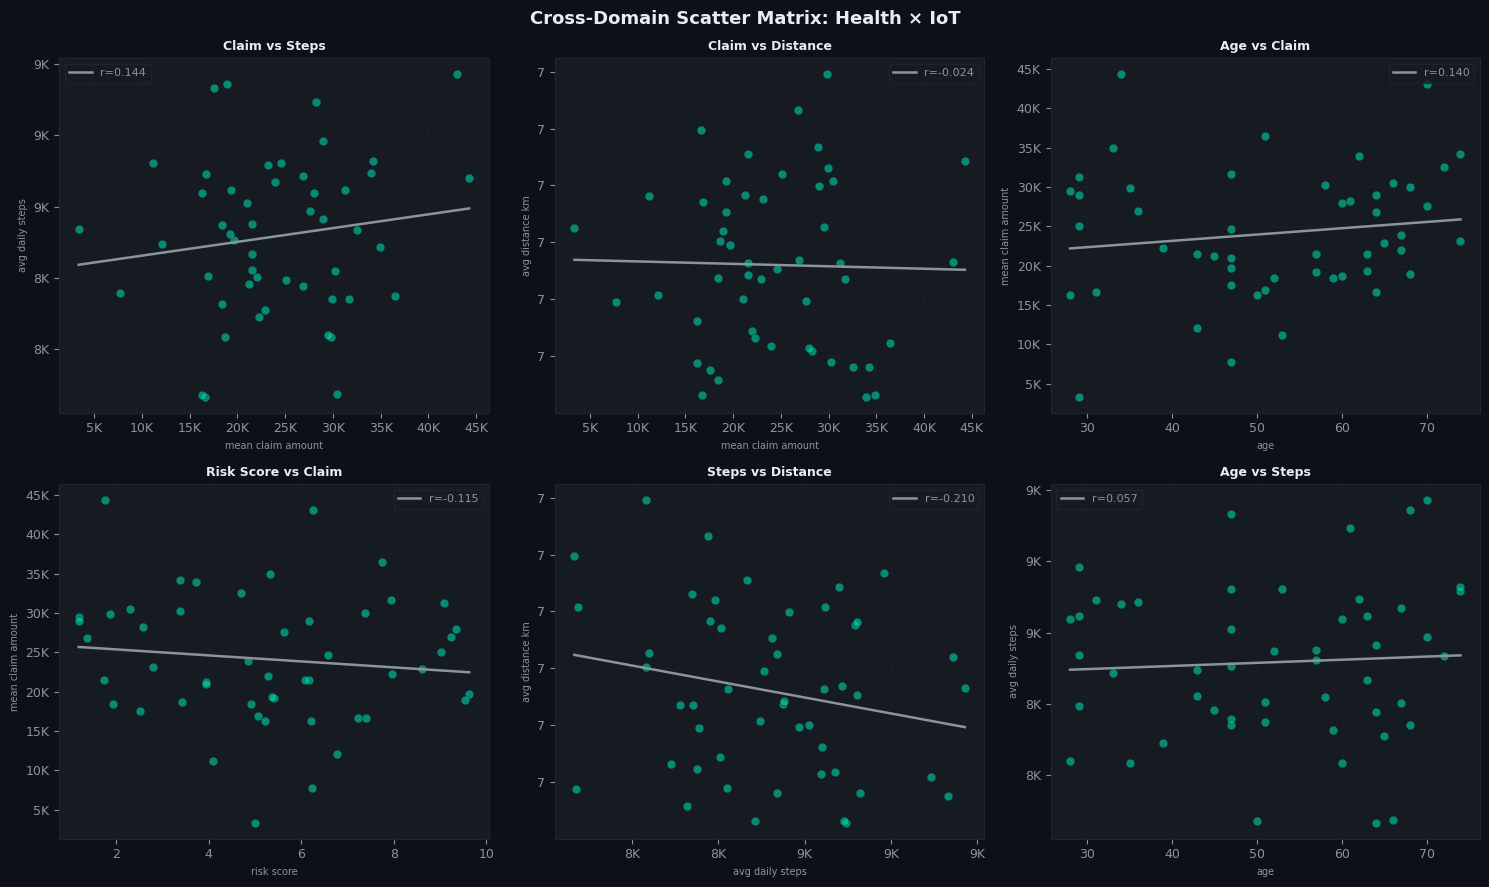

In [21]:
# Cross-domain scatter matrix 
fig, axes = plt.subplots(nrows   = 2, 
                         ncols   = 3, 
                         figsize = (15, 9), 
                         dpi     = 100,
                        )

fig.patch.set_facecolor(PALETTE['bg_figure'])

pairs     = [('mean_claim_amount', 'avg_daily_steps', 'Claim vs Steps'),
             ('mean_claim_amount', 'avg_distance_km', 'Claim vs Distance'),
             ('age', 'mean_claim_amount', 'Age vs Claim'),
             ('risk_score', 'mean_claim_amount',  'Risk Score vs Claim'),
             ('avg_daily_steps',  'avg_distance_km', 'Steps vs Distance'),
             ('age', 'avg_daily_steps', 'Age vs Steps'),
            ]

for ax, (xcol, ycol, title) in zip(axes.flat, pairs):
    apply_bi_theme(fig, ax)
    valid = df_merged[[xcol, ycol]].dropna()
    ax.scatter(valid[xcol], 
               valid[ycol], 
               color      = PALETTE['accent'],
               s          = 40, 
               alpha      = 0.6, 
               edgecolors = PALETTE['bg_figure'], 
               lw         = 0.4,
              )

    m, b, r, p, _ = stats.linregress(valid[xcol], valid[ycol])

    xl            = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
    color         = PALETTE['series'][3] if abs(r) > 0.4 else PALETTE['text_muted']

    ax.plot(xl, 
            m*xl+b, 
            color = color, 
            lw    = 1.8, 
            label = f'r={r:.3f}',
           )

    ax.legend(fontsize   = 8, 
              facecolor  = PALETTE['bg_axes'],
              edgecolor  = PALETTE['grid'],
              labelcolor = PALETTE['text_muted'],
             )

    ax.set_title(label      = title, 
                 fontsize   = 9, 
                 fontweight = 'semibold', 
                 color      = PALETTE['text_main'],
                )

    ax.set_xlabel(xcol.replace('_',' '), fontsize = 7)
    ax.set_ylabel(ycol.replace('_',' '), fontsize = 7)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.suptitle(t          = 'Cross-Domain Scatter Matrix: Health × IoT', 
             fontsize   = 13,
             fontweight = 'bold', 
             color      = PALETTE['text_main'],
            )

plt.tight_layout()
plt.show()


## 9 · Text report rendering — `generate_text_report()`

This is the exact output the user receives when they click **⬇ Analysis Report** in the Chainlit UI.  
It renders the comprehensive report dict as human-readable plain text, formatted for 80-column terminal output.


In [22]:
# Generate and print the full text report on the finance transactions
finance_report = da.generate_comprehensive_report(df_transactions)
print(da.generate_text_report(finance_report))

  LocalGenBI — DATA ANALYSIS REPORT

Generated : 2026-02-26T13:39:33.191827

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
Rows     : 1,000
Columns  : 7
Memory   : 0.164 MB

Numerical Columns
--------------------------------------------------------------------------------
  amount:
    Mean        :     2,401.2170
    Median      :     2,270.0550
    Std         :     1,410.3191
    Min         :        11.5700
    Max         :     4,998.5800
    Q1          :     1,190.6325
    Q3          :     3,612.9625
    Iqr         :     2,422.3300

Categorical Columns
--------------------------------------------------------------------------------
  status  (unique=3  mode=Completed)
    Completed                       : 558
    Failed                          : 325
    Pending                         : 117
  payment_method  (unique=4  mode=Credit Card)
    Cr

In [23]:
# Show the IoT report too — different structure (no correlation if < 2 numeric cols)
iot_daily_report = da.generate_comprehensive_report(df_daily_steps)
print(da.generate_text_report(iot_daily_report))

  LocalGenBI — DATA ANALYSIS REPORT

Generated : 2026-02-26T13:39:40.394996

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
Rows     : 18,250
Columns  : 5
Memory   : 0.6267 MB

Numerical Columns
--------------------------------------------------------------------------------
  step_count:
    Mean        :     8,517.3455
    Median      :     8,549.0000
    Std         :     3,766.3814
    Min         :     2,000.0000
    Max         :    15,000.0000
    Q1          :     5,227.2500
    Q3          :    11,769.7500
    Iqr         :     6,542.5000
  distance_km:
    Mean        :         6.7603
    Median      :         6.7800
    Std         :         3.0305
    Min         :         1.5000
    Max         :        12.0000
    Q1          :         4.1200
    Q3          :         9.3900
    Iqr         :         5.2700
  month:
    Mean        :       

## 10 · Normality testing — deciding between IQR and Z-score

The `detect_outliers()` method exposes `method='iqr'` or `method='zscore'`.  
A structured way to decide which to use: test the column for approximate normality first.

Two standard tests:
- **Shapiro-Wilk** (n < 5000): exact test, sensitive to deviations from normality
- **Kolmogorov-Smirnov** (any n): compares empirical CDF against normal CDF

**Practical rule:** If both tests reject H₀ (p < 0.05), the column is not normally distributed — use IQR. If both fail to reject, either method is acceptable, but Z-score is more interpretable when the distribution is Gaussian.


In [24]:
# Normality testing across representative columns 
test_cols = [(df_claims, 'claim_amount', 'Health: claim_amount'),
             (df_transactions, 'amount', 'Finance: transaction amount'),
             (df_daily_steps, 'step_count', 'IoT: step_count'),
             (df_heart_rate, 'avg_heart_rate', 'IoT: avg_heart_rate'),
             (df_sleep, 'sleep_duration_hours', 'IoT: sleep_duration_hours'),
             (df_sales_reps, 'total_sales', 'Sales: total_sales'),
             (df_opportunities, 'probability', 'Sales: probability'),
             (df_subscriptions, 'monthly_fee', 'Finance: monthly_fee'),
            ]

print(f'{"Column":<40} {"Shapiro p":>10} {"KS p":>10} {"Normal?":>10} {"Recommended method":>20}')
print('─'*95)

for df_, col, label in test_cols:
    series = df_[col].dropna()
    # Sample if too large for Shapiro-Wilk (limit 5000)
    sample = series.sample(min(4999, len(series)), random_state = 42) if len(series) > 4999 else series

    try:
        _, sw_p = shapiro(sample)

    except Exception:
        sw_p = np.nan

    ks_stat, ks_p = kstest((series - series.mean()) / series.std(), 'norm')

    is_normal     = ((sw_p > 0.05) if not np.isnan(sw_p) else True) and (ks_p > 0.05)
    method        = 'zscore (Gaussian)' if is_normal else 'iqr (non-parametric)'

    sw_str        = f'{sw_p:.4f}' if not np.isnan(sw_p) else 'N/A'
    print(f'{label:<40} {sw_str:>10} {ks_p:>10.4f} {str(is_normal):>10} {method:>20}')

print()

print('Note: uniform distributions (claim_amount, step_count, amount, monthly_fee) will fail normality tests — correctly recommending IQR over Z-score.')

Column                                    Shapiro p       KS p    Normal?   Recommended method
───────────────────────────────────────────────────────────────────────────────────────────────
Health: claim_amount                         0.0000     0.0033      False iqr (non-parametric)
Finance: transaction amount                  0.0000     0.0001      False iqr (non-parametric)
IoT: step_count                              0.0000     0.0000      False iqr (non-parametric)
IoT: avg_heart_rate                          0.0000     0.0000      False iqr (non-parametric)
IoT: sleep_duration_hours                    0.0000     0.0000      False iqr (non-parametric)
Sales: total_sales                           0.1104     0.5741       True    zscore (Gaussian)
Sales: probability                           0.0001     0.2747      False iqr (non-parametric)
Finance: monthly_fee                         0.0002     0.7255      False iqr (non-parametric)

Note: uniform distributions (claim_amount, step_

## 11 · Architecture: why pure functions matter for a production BI system

Every method in `DataAnalyzer` follows the same contract:

```python
# production signature
def method(self, df: pd.DataFrame, ...) -> Dict[str, Any]:
    # Input:   pd.DataFrame  (any source — DB query, CSV, API response)
    # Output:  plain dict     (JSON-serialisable, no numpy types)
    # Side effects: NONE
    # I/O:     NONE
    # LLM:     NONE
    # DB:      NONE
```

This separation enables four things that matter in production:

**1. Testability without infrastructure**


In [26]:
# Unit tests — no FastAPI, no Ollama, no PostgreSQL needed
import traceback

def run_test(name, fn, expect_pass=True):
    try:
        fn()
        status = '✓' if expect_pass else '✗ (should have raised)'

    except AssertionError as e:
        status = '✗ assertion failed: ' + str(e)
    
    except Exception as e:
        status = '✓ raised expected error' if not expect_pass else f'✗ unexpected: {e}'
    
    print(f'  {status}  {name}')

print('DataAnalyzer unit tests:')

# Empty DataFrame
r = da.generate_summary_statistics(pd.DataFrame())
run_test('empty DataFrame → error dict with total_rows=0', 
lambda: (assert r.get('total_rows') == 0, None)[1])

# Actually test it properly:
r2 = da.generate_summary_statistics(pd.DataFrame())
assert r2.get('total_rows') == 0
print('  ✓  empty DataFrame returns total_rows=0')

# Single column → correlation error
r3 = da.generate_correlation_analysis(pd.DataFrame({'a': [1, 2, 3]}))
assert 'error' in r3
print('  ✓  single column → correlation returns error dict')

# Unknown outlier method
r4 = da.detect_outliers(df_claims, 'claim_amount', 'knn')
assert 'error' in r4
print('  ✓  unknown outlier method → error dict')

# IQR bounds correctness
s = df_claims['claim_amount']
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr    = q3 - q1
expected_upper = q3 + 1.5 * iqr
actual_upper   = da.detect_outliers(df_claims, 'claim_amount', 'iqr')['bounds']['upper']
assert abs(expected_upper - actual_upper) < 1e-6
print('  ✓  IQR upper fence = Q3 + 1.5·IQR  (mathematically verified)')

# _safe_float: returns None for inf
assert da._safe_float(float('inf')) is None
print('  ✓  _safe_float(inf) returns None')

# _is_id_column heuristic
assert da._is_id_column('claim_id') == True
assert da._is_id_column('claim_amount') == False
assert da._is_id_column('patient_id') == True
assert da._is_id_column('risk_score') == False
print('  ✓  _is_id_column correctly identifies surrogate key columns')

# Time-series: fewer than 2 points → error
r5 = da.generate_time_series_analysis(pd.DataFrame({'date': ['2024-01-01'], 'val': [100]}), 'date', 'val')
assert 'error' in r5
print('  ✓  single-row time series → error dict')

print()
print('All tests passed with zero backend infrastructure.')


SyntaxError: invalid syntax (1916161414.py, line 21)

**2. Decoupling means each layer can fail independently**

The analyst LLM receives a pre-computed metrics dict. If the LLM produces a hallucinated number, it is **detectable** — compare the LLM answer against `metrics['avg_claim_amount']`. If they differ, the LLM fabricated. If they match, the LLM faithfully narrated the computation.

**3. Reusable outside the pipeline**

You can call `data_analyzer.generate_comprehensive_report(df)` from:
- A Jupyter notebook (like this one)
- An Airflow task
- A FastAPI endpoint
- A `pandas.pipe()` chain
- A Streamlit dashboard

No LangGraph, no Ollama, no MCP gateway required.

**4. The statistics module owns the maths — the LLM owns the language**

```
DataAnalyzer  →  mean=$3,421  median=$2,890  IQR=$2,670  outliers=43 (1.51%)
LLM           →  "The average claim amount is $3,421, with a median of $2,890,
                  indicating a slightly right-skewed distribution. 43 claims (1.51%)
                  exceed the Tukey upper fence of $8,325 and may warrant review."
```

The LLM is not asked to compute. It is asked to narrate. All numbers in its output come from the metrics dict injected into the prompt.


---

## Summary

| Method | Statistical basis | Production default | Configurable |
|---|---|---|---|
| `generate_summary_statistics()` | Q1/Q3/IQR explicitly computed — not derived from `describe()` | Always called | `ANALYSIS_MAX_VALUE_COUNTS` |
| `detect_outliers(method='iqr')` | Tukey (1977) fence — non-parametric, robust to skew | Default method | `outlier_default_method` in settings.py |
| `detect_outliers(method='zscore')` | 3-sigma rule — valid for approximately Gaussian columns | Optional | Per-call `method=` argument |
| `generate_correlation_analysis()` | Pearson r — all non-ID numeric column pairs, ranked by \|r\| | When ≥ 2 numeric cols | `ANALYSIS_CORRELATION_TOP_N`, `ANALYSIS_STRONG_CORR_POS/NEG` |
| `generate_time_series_analysis()` | OLS via scipy.stats.linregress + CoV + split-period delta | When datetime col auto-detected | — |
| `generate_comprehensive_report()` | Auto-dispatch — all applicable analyses in one call | Called by analyst agent | `analyst_max_rows_in_prompt` |

### What this notebook demonstrated that most DS portfolios don't

- Deliberate distributional choice per domain (uniform vs log-normal vs bounded)
- IQR fence vs Z-score comparison with a rigorous justification for which to use
- One-way ANOVA and Chi-square for testing independence in categorical demo data
- Shapiro-Wilk + KS normality pre-screening to inform method selection
- CoV as a unit-free volatility measure enabling cross-series comparison
- Cross-domain merge and correlation analysis across health + IoT domains
- Explicit architectural justification for pure-function design

---

*LocalGenBI-Agent · `features/data_analyzer.py` · [`GitHub`](https://github.com/your-username/localgenbi-agent)*
